In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
import kagglehub
import os

In [ ]:
path = kagglehub.dataset_download("zanarmuratova/anime-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'anime-dataset' dataset.
Path to dataset files: /kaggle/input/anime-dataset


In [ ]:
files = os.listdir(path)
print(files)

['anime.csv']


In [ ]:
file_name = 'anime.csv'
full_path = os.path.join(path, file_name)

df_main = pd.read_csv(full_path)
print(df_main.head())

                                      title  score  people_scored  \
0                         Sousou no Frieren   9.27         869731   
1  Steel Ball Run: JoJo no Kimyou na Bouken   9.16          86411   
2          Fullmetal Alchemist: Brotherhood   9.11        2303444   
3              Chainsaw Man Movie: Reze-hen   9.09         282353   
4                               Steins;Gate   9.07        1516022   

         popularity            members       season title_type  \
0   Popularity #104  Members 1,411,377    Fall 2023         TV   
1  Popularity #1447    Members 189,929          NaN        ONA   
2     Popularity #3  Members 3,667,785  Spring 2009         TV   
3   Popularity #589    Members 449,212          NaN      Movie   
4    Popularity #14  Members 2,802,086  Spring 2011         TV   

             studio                                        description  \
0          Madhouse  During their decade-long quest to defeat the D...   
1  David Production  In the American Old

In [ ]:
print(df_main.columns)

Index(['title', 'score', 'people_scored', 'popularity', 'members', 'season',
       'title_type', 'studio', 'description', 'recommended', 'mixed_feelings',
       'not_recommended', 'rec', 'mix', 'not_rec', 'english_title',
       'show_type', 'status', 'aired', 'broadcast', 'producers', 'licensors',
       'source', 'genres', 'duration', 'episodes', 'rating', 'themes',
       'demographics', 'favorites'],
      dtype='object')


In [ ]:
print(df_main.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10142 entries, 0 to 10141
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            10142 non-null  object 
 1   score            10142 non-null  float64
 2   people_scored    10142 non-null  int64  
 3   popularity       10142 non-null  object 
 4   members          10142 non-null  object 
 5   season           4427 non-null   object 
 6   title_type       10142 non-null  object 
 7   studio           9717 non-null   object 
 8   description      10142 non-null  object 
 9   recommended      10142 non-null  int64  
 10  mixed_feelings   10142 non-null  int64  
 11  not_recommended  10142 non-null  int64  
 12  rec              8198 non-null   object 
 13  mix              6870 non-null   object 
 14  not_rec          6004 non-null   object 
 15  english_title    7041 non-null   object 
 16  show_type        10142 non-null  object 
 17  status      

#CLEANING

In [ ]:
df = df_main.copy()

Below i took columns popularity, members, favourites and episodes and formated them to be numeric values which will aid us later in analysis

In [ ]:
# 1. Clean popularity
df['popularity'] = (
    df['popularity']
    .str.replace('Popularity', '', regex=False)
    .str.replace('#', '', regex=False)
    .str.strip()
)
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

# 2. Clean members
df['members'] = (
    df['members']
    .str.replace('Members', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['members'] = pd.to_numeric(df['members'], errors='coerce')

# 3. Clean favorites
df['favorites'] = (
    df['favorites']
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['favorites'] = pd.to_numeric(df['favorites'], errors='coerce')

# 4. Clean episodes
df['episodes'] = (
    df['episodes']
    .replace('Unknown', np.nan)
)
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
df.head()

,title,score,people_scored,popularity,members,season,title_type,studio,description,recommended,...,producers,licensors,source,genres,duration,episodes,rating,themes,demographics,favorites
0,Sousou no Frieren,9.27,869731,104,1411377,Fall 2023,TV,Madhouse,During their decade-long quest to defeat the D...,819,...,"Aniplex, Dentsu, Shogakukan-Shueis...",Crunchyroll,Manga,"AdventureAdventure, Award WinningAward...",24 min. per ep.,28.0,PG-13 - Teens 13 or older,NaN,ShounenShounen,88070
1,Steel Ball Run: JoJo no Kimyou na Bouken,9.16,86411,1447,189929,NaN,ONA,David Production,"In the American Old West, the world's greatest...",156,...,"Warner Bros. Japan, Studio Mausu, ...","None found, add some",Manga,"ActionAction, AdventureAdventure, ...",47 min.,NaN,R - 17+ (violence & profanity),"HistoricalHistorical, RacingRacing","SeinenSeinen, ShounenShounen",6051
2,Fullmetal Alchemist: Brotherhood,9.11,2303444,3,3667785,Spring 2009,TV,Bones,After a horrific alchemy experiment goes wrong...,971,...,"Aniplex, Square Enix, Mainichi Bro...","Funimation, Aniplex of America",Manga,"ActionAction, AdventureAdventure, ...",24 min. per ep.,64.0,R - 17+ (violence & profanity),MilitaryMilitary,ShounenShounen,241796
3,Chainsaw Man Movie: Reze-hen,9.09,282353,589,449212,NaN,Movie,MAPPA,Despite the immediate challenges following bec...,322,...,"None found, add some","None found, add some",Manga,"ActionAction, FantasyFantasy",1 hr. 39 min.,1.0,R - 17+ (violence & profanity),"GoreGore, Urban FantasyUrban Fantasy",ShounenShounen,12951
4,Steins;Gate,9.07,1516022,14,2802086,Spring 2011,TV,White Fox,Eccentric scientist Rintarou Okabe has a never...,1075,...,"Frontier Works, Media Factory, Kad...",Funimation,Visual novel,"DramaDrama, Sci-FiSci-Fi, Susp...",24 min. per ep.,24.0,PG-13 - Teens 13 or older,"PsychologicalPsychological, Time Trave...",NaN,201780


Below i converted the duration column to duration_min for the purpose of later analysis

In [ ]:

def convert_duration(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower()

    if 'unknown' in x:
        return np.nan

    hours = 0
    minutes = 0

    # Extract hours
    hr_match = re.search(r'(\d+)\s*hr', x)
    if hr_match:
        hours = int(hr_match.group(1))

    # Extract minutes
    min_match = re.search(r'(\d+)\s*min', x)
    if min_match:
        minutes = int(min_match.group(1))

    total_minutes = hours * 60 + minutes

    return total_minutes if total_minutes > 0 else np.nan


df['duration'] = df['duration'].apply(convert_duration)
df.rename(columns={'duration': 'duration_min'}, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10142 entries, 0 to 10141
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            10142 non-null  object 
 1   score            10142 non-null  float64
 2   people_scored    10142 non-null  int64  
 3   popularity       10142 non-null  int64  
 4   members          10142 non-null  int64  
 5   season           4427 non-null   object 
 6   title_type       10142 non-null  object 
 7   studio           9717 non-null   object 
 8   description      10142 non-null  object 
 9   recommended      10142 non-null  int64  
 10  mixed_feelings   10142 non-null  int64  
 11  not_recommended  10142 non-null  int64  
 12  rec              8198 non-null   object 
 13  mix              6870 non-null   object 
 14  not_rec          6004 non-null   object 
 15  english_title    7041 non-null   object 
 16  show_type        10142 non-null  object 
 17  status      

In [ ]:

pd.set_option('display.max_columns', None)
df.head()

,title,score,people_scored,popularity,members,season,title_type,studio,description,recommended,mixed_feelings,not_recommended,rec,mix,not_rec,english_title,show_type,status,aired,broadcast,producers,licensors,source,genres,duration_min,episodes,rating,themes,demographics,favorites
0,Sousou no Frieren,9.27,869731,104,1411377,Fall 2023,TV,Madhouse,During their decade-long quest to defeat the D...,819,144,116,I feel so catered to.\r\n\r\nIt feels like an ...,Someone recommended me to watch this title las...,Style-\r\nFrieren doesn't have its own unique ...,Frieren: Beyond Journey's End,TV,Finished Airing,"Sep 29, 2023 to Mar 22, 2024",Fridays at 23:00 (JST),"Aniplex, Dentsu, Shogakukan-Shueis...",Crunchyroll,Manga,"AdventureAdventure, Award WinningAward...",24.0,28.0,PG-13 - Teens 13 or older,NaN,ShounenShounen,88070
1,Steel Ball Run: JoJo no Kimyou na Bouken,9.16,86411,1447,189929,NaN,ONA,David Production,"In the American Old West, the world's greatest...",156,7,1,I watched the first episode and it was truly a...,I will summarize it for you in two words.\r\nN...,The part 7 adaption is similar to its previous...,Steel Ball Run: JoJo's Bizarre Adventure,ONA,Currently Airing,"Mar 19, 2026 to ?",NaN,"Warner Bros. Japan, Studio Mausu, ...","None found, add some",Manga,"ActionAction, AdventureAdventure, ...",47.0,NaN,R - 17+ (violence & profanity),"HistoricalHistorical, RacingRacing","SeinenSeinen, ShounenShounen",6051
2,Fullmetal Alchemist: Brotherhood,9.11,2303444,3,3667785,Spring 2009,TV,Bones,After a horrific alchemy experiment goes wrong...,971,69,44,"First of all, I have seen the original FMA and...",Fullmetal Alchemist: Brotherhood gets an immen...,*Spoiler Warning\r\n\r\nAside from the usual e...,Fullmetal Alchemist: Brotherhood,TV,Finished Airing,"Apr 5, 2009 to Jul 4, 2010",Sundays at 17:00 (JST),"Aniplex, Square Enix, Mainichi Bro...","Funimation, Aniplex of America",Manga,"ActionAction, AdventureAdventure, ...",24.0,64.0,R - 17+ (violence & profanity),MilitaryMilitary,ShounenShounen,241796
3,Chainsaw Man Movie: Reze-hen,9.09,282353,589,449212,NaN,Movie,MAPPA,Despite the immediate challenges following bec...,322,46,19,In short if you like and read the chainsaw man...,Quick little review because I feel my perspect...,Writing this review to compile my thoughts on ...,Chainsaw Man – The Movie: Reze Arc,Movie,Finished Airing,"Sep 19, 2025",NaN,"None found, add some","None found, add some",Manga,"ActionAction, FantasyFantasy",99.0,1.0,R - 17+ (violence & profanity),"GoreGore, Urban FantasyUrban Fantasy",ShounenShounen,12951
4,Steins;Gate,9.07,1516022,14,2802086,Spring 2011,TV,White Fox,Eccentric scientist Rintarou Okabe has a never...,1075,88,84,“No one knows what the future holds. That’s wh...,One word: Hype.\r\n\r\nBefore watching this sh...,Just a horrible anime. This is the anime equiv...,Steins;Gate,TV,Finished Airing,"Apr 6, 2011 to Sep 14, 2011",Wednesdays at 02:05 (JST),"Frontier Works, Media Factory, Kad...",Funimation,Visual novel,"DramaDrama, Sci-FiSci-Fi, Susp...",24.0,24.0,PG-13 - Teens 13 or older,"PsychologicalPsychological, Time Trave...",NaN,201780


I dropped "title_type" as its identical to our show_type column

In [ ]:
df.drop(['title_type'], axis=1,inplace= True)

I took all string values in the dataframe and put them all into a consistent format

In [ ]:
str_cols = df.select_dtypes(include='object').columns

df[str_cols] = df[str_cols].apply(lambda x: x.str.lower().str.strip())

From the broadcast column i engineered "broadcast_day" and "broadcast_time" so that we may be able to see trends in how different days and different hours of release affect our data

In [ ]:

# Extract day
df['broadcast_day'] = df['broadcast'].str.extract(r'(\w+)', expand=False)

# Extract time
df['broadcast_time'] = df['broadcast'].str.extract(r'(\d{2}:\d{2})', expand=False)

# Convert time to datetime (time format)
df['broadcast_time'] = pd.to_datetime(
    df['broadcast'].str.extract(r'(\d{2}:\d{2})')[0],
    format='%H:%M',
    errors='coerce'
).dt.time

In [ ]:
df['demographics'].value_counts()

,count
demographics,
shounenshounen,1806
seinenseinen,887
kidskids,532
shoujoshoujo,389
joseijosei,114
"kidskids, shounenshounen",46
"seinenseinen, shounenshounen",1
"kidskids, shoujoshoujo",1


columns like genres and themes have repeating string values in the same cell, this was handled below

In [ ]:

def fix_joined_repeat(text):
    if pd.isna(text):
        return np.nan

    parts = [p.strip() for p in str(text).split(',')]
    cleaned_parts = []

    for part in parts:
        if len(part) % 2 == 0 and part[:len(part)//2] == part[len(part)//2:]:
            cleaned_parts.append(part[:len(part)//2])
        else:
            cleaned_parts.append(part)

    return ', '.join(cleaned_parts)

df['demographics'] = df['demographics'].apply(fix_joined_repeat)
df['genres'] = df['genres'].apply(fix_joined_repeat)
df['themes'] = df['themes'].apply(fix_joined_repeat)

In [ ]:
df['genres'].value_counts()

,count
genres,
comedy,937
"action, adventure, fantasy",478
slice of life,301
"comedy, romance",293
sci-fi,269
...,...
"action, gourmet, sci-fi",1
"action, adventure, comedy, romance, ecchi",1
"comedy, girls love, sci-fi",1


In [ ]:
df.head()

,title,score,people_scored,popularity,members,season,studio,description,recommended,mixed_feelings,not_recommended,rec,mix,not_rec,english_title,show_type,status,aired,broadcast,producers,licensors,source,genres,duration_min,episodes,rating,themes,demographics,favorites,broadcast_day,broadcast_time
0,sousou no frieren,9.27,869731,104,1411377,fall 2023,madhouse,during their decade-long quest to defeat the d...,819,144,116,i feel so catered to.\r\n\r\nit feels like an ...,someone recommended me to watch this title las...,style-\r\nfrieren doesn't have its own unique ...,frieren: beyond journey's end,tv,finished airing,"sep 29, 2023 to mar 22, 2024",fridays at 23:00 (jst),"aniplex, dentsu, shogakukan-shueis...",crunchyroll,manga,"adventure, award winning, drama, fantasy",24.0,28.0,pg-13 - teens 13 or older,NaN,shounen,88070,fridays,23:00:00
1,steel ball run: jojo no kimyou na bouken,9.16,86411,1447,189929,NaN,david production,"in the american old west, the world's greatest...",156,7,1,i watched the first episode and it was truly a...,i will summarize it for you in two words.\r\nn...,the part 7 adaption is similar to its previous...,steel ball run: jojo's bizarre adventure,ona,currently airing,"mar 19, 2026 to ?",NaN,"warner bros. japan, studio mausu, ...","none found, add some",manga,"action, adventure, mystery, supernatural",47.0,NaN,r - 17+ (violence & profanity),"historical, racing","seinen, shounen",6051,NaN,NaT
2,fullmetal alchemist: brotherhood,9.11,2303444,3,3667785,spring 2009,bones,after a horrific alchemy experiment goes wrong...,971,69,44,"first of all, i have seen the original fma and...",fullmetal alchemist: brotherhood gets an immen...,*spoiler warning\r\n\r\naside from the usual e...,fullmetal alchemist: brotherhood,tv,finished airing,"apr 5, 2009 to jul 4, 2010",sundays at 17:00 (jst),"aniplex, square enix, mainichi bro...","funimation, aniplex of america",manga,"action, adventure, drama, fantasy",24.0,64.0,r - 17+ (violence & profanity),military,shounen,241796,sundays,17:00:00
3,chainsaw man movie: reze-hen,9.09,282353,589,449212,NaN,mappa,despite the immediate challenges following bec...,322,46,19,in short if you like and read the chainsaw man...,quick little review because i feel my perspect...,writing this review to compile my thoughts on ...,chainsaw man – the movie: reze arc,movie,finished airing,"sep 19, 2025",NaN,"none found, add some","none found, add some",manga,"action, fantasy",99.0,1.0,r - 17+ (violence & profanity),"gore, urban fantasy",shounen,12951,NaN,NaT
4,steins;gate,9.07,1516022,14,2802086,spring 2011,white fox,eccentric scientist rintarou okabe has a never...,1075,88,84,“no one knows what the future holds. that’s wh...,one word: hype.\r\n\r\nbefore watching this sh...,just a horrible anime. this is the anime equiv...,steins;gate,tv,finished airing,"apr 6, 2011 to sep 14, 2011",wednesdays at 02:05 (jst),"frontier works, media factory, kad...",funimation,visual novel,"drama, sci-fi, suspense",24.0,24.0,pg-13 - teens 13 or older,"psychological, time travel",NaN,201780,wednesdays,02:05:00


ensuring all "unknown" values in our data are replaced with null value, and light formating of broadcast_day

In [ ]:
for i in str_cols:
    df[i] = df[i].replace({
    'unknown': np.nan,
    'not': np.nan,
    'none found, add some': np.nan
})

df['broadcast_day'] = (
    df['broadcast_day']
    .str.replace('s$', '', regex=True)   # remove 's' at end
    .str.capitalize()
)

days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df['broadcast_day'] = pd.Categorical(
    df['broadcast_day'],
    categories=days_order,
    ordered=True
)

In [ ]:
df['broadcast_day'].value_counts().sort_index()

,count
broadcast_day,
Monday,366
Tuesday,428
Wednesday,387
Thursday,441
Friday,605
Saturday,706
Sunday,769


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10142 entries, 0 to 10141
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   title            10142 non-null  object  
 1   score            10142 non-null  float64 
 2   people_scored    10142 non-null  int64   
 3   popularity       10142 non-null  int64   
 4   members          10142 non-null  int64   
 5   season           4427 non-null   object  
 6   studio           9717 non-null   object  
 7   description      10142 non-null  object  
 8   recommended      10142 non-null  int64   
 9   mixed_feelings   10142 non-null  int64   
 10  not_recommended  10142 non-null  int64   
 11  rec              8198 non-null   object  
 12  mix              6870 non-null   object  
 13  not_rec          6004 non-null   object  
 14  english_title    7041 non-null   object  
 15  show_type        10142 non-null  object  
 16  status           10142 non-null  object 

In [ ]:
df.head()

,title,score,people_scored,popularity,members,season,studio,description,recommended,mixed_feelings,not_recommended,rec,mix,not_rec,english_title,show_type,status,aired,broadcast,producers,licensors,source,genres,duration_min,episodes,rating,themes,demographics,favorites,broadcast_day,broadcast_time
0,sousou no frieren,9.27,869731,104,1411377,fall 2023,madhouse,during their decade-long quest to defeat the d...,819,144,116,i feel so catered to.\r\n\r\nit feels like an ...,someone recommended me to watch this title las...,style-\r\nfrieren doesn't have its own unique ...,frieren: beyond journey's end,tv,finished airing,"sep 29, 2023 to mar 22, 2024",fridays at 23:00 (jst),"aniplex, dentsu, shogakukan-shueis...",crunchyroll,manga,"adventure, award winning, drama, fantasy",24.0,28.0,pg-13 - teens 13 or older,NaN,shounen,88070,Friday,23:00:00
1,steel ball run: jojo no kimyou na bouken,9.16,86411,1447,189929,NaN,david production,"in the american old west, the world's greatest...",156,7,1,i watched the first episode and it was truly a...,i will summarize it for you in two words.\r\nn...,the part 7 adaption is similar to its previous...,steel ball run: jojo's bizarre adventure,ona,currently airing,"mar 19, 2026 to ?",NaN,"warner bros. japan, studio mausu, ...",NaN,manga,"action, adventure, mystery, supernatural",47.0,NaN,r - 17+ (violence & profanity),"historical, racing","seinen, shounen",6051,NaN,NaT
2,fullmetal alchemist: brotherhood,9.11,2303444,3,3667785,spring 2009,bones,after a horrific alchemy experiment goes wrong...,971,69,44,"first of all, i have seen the original fma and...",fullmetal alchemist: brotherhood gets an immen...,*spoiler warning\r\n\r\naside from the usual e...,fullmetal alchemist: brotherhood,tv,finished airing,"apr 5, 2009 to jul 4, 2010",sundays at 17:00 (jst),"aniplex, square enix, mainichi bro...","funimation, aniplex of america",manga,"action, adventure, drama, fantasy",24.0,64.0,r - 17+ (violence & profanity),military,shounen,241796,Sunday,17:00:00
3,chainsaw man movie: reze-hen,9.09,282353,589,449212,NaN,mappa,despite the immediate challenges following bec...,322,46,19,in short if you like and read the chainsaw man...,quick little review because i feel my perspect...,writing this review to compile my thoughts on ...,chainsaw man – the movie: reze arc,movie,finished airing,"sep 19, 2025",NaN,NaN,NaN,manga,"action, fantasy",99.0,1.0,r - 17+ (violence & profanity),"gore, urban fantasy",shounen,12951,NaN,NaT
4,steins;gate,9.07,1516022,14,2802086,spring 2011,white fox,eccentric scientist rintarou okabe has a never...,1075,88,84,“no one knows what the future holds. that’s wh...,one word: hype.\r\n\r\nbefore watching this sh...,just a horrible anime. this is the anime equiv...,steins;gate,tv,finished airing,"apr 6, 2011 to sep 14, 2011",wednesdays at 02:05 (jst),"frontier works, media factory, kad...",funimation,visual novel,"drama, sci-fi, suspense",24.0,24.0,pg-13 - teens 13 or older,"psychological, time travel",NaN,201780,Wednesday,02:05:00


In [ ]:
airing = df['aired']

In [ ]:
print(airing)

0        sep 29, 2023 to mar 22, 2024
1                   mar 19, 2026 to ?
2          apr 5, 2009 to jul 4, 2010
3                        sep 19, 2025
4         apr 6, 2011 to sep 14, 2011
                     ...             
10137     apr 5, 2017 to feb 28, 2018
10138                    jul 15, 1995
10139                     apr 1, 2020
10140                     aug 8, 2014
10141     jul 9, 2025 to sep 24, 2025
Name: aired, Length: 10142, dtype: object


In [ ]:
def extract_dates(series):
  columns = series.split('to')
  if len(columns) == 2:
    start_date = columns[0].strip()
    end_date = columns[1].strip()
  elif len(columns) == 1:
    start_date = columns[0].strip()
    end_date = None
  else:
    start_date = None
    end_date = None
  return pd.Series([start_date, end_date], index=['start_date', 'end_date'])

In [ ]:
experiment = airing.apply(extract_dates)
print(experiment)

         start_date      end_date
0      sep 29, 2023  mar 22, 2024
1      mar 19, 2026             ?
2       apr 5, 2009   jul 4, 2010
3      sep 19, 2025          None
4       apr 6, 2011  sep 14, 2011
...             ...           ...
10137   apr 5, 2017  feb 28, 2018
10138  jul 15, 1995          None
10139   apr 1, 2020          None
10140   aug 8, 2014          None
10141   jul 9, 2025  sep 24, 2025

[10142 rows x 2 columns]


In [ ]:
experiment['start_date'] = pd.to_datetime(experiment['start_date'], format='%b %d, %Y', errors='coerce')
experiment['end_date'] = pd.to_datetime(experiment['end_date'], format='%b %d, %Y', errors='coerce')

print(experiment)

      start_date   end_date
0     2023-09-29 2024-03-22
1     2026-03-19        NaT
2     2009-04-05 2010-07-04
3     2025-09-19        NaT
4     2011-04-06 2011-09-14
...          ...        ...
10137 2017-04-05 2018-02-28
10138 1995-07-15        NaT
10139 2020-04-01        NaT
10140 2014-08-08        NaT
10141 2025-07-09 2025-09-24

[10142 rows x 2 columns]


In [ ]:
df['start_date'] = experiment['start_date']
df['end_date'] = experiment['end_date']
df.drop(['aired'], axis=1, inplace=True)

In [ ]:
def define_season(month, year):
    if month in [12, 1, 2]:
        return f'winter {year}'
    elif month in [3, 4, 5]:
        return f'spring {year}'
    elif month in [6, 7,8]:
        return f'summer {year}'
    elif month in [9, 10, 11]:
        return f'fall {year}'

In [ ]:
df['season'] = df['start_date'].apply(lambda x: define_season(x.month, x.year) if pd.notnull(x) else None)

In [ ]:
print(df.head())

                                      title  score  people_scored  popularity  \
0                         sousou no frieren   9.27         869731         104   
1  steel ball run: jojo no kimyou na bouken   9.16          86411        1447   
2          fullmetal alchemist: brotherhood   9.11        2303444           3   
3              chainsaw man movie: reze-hen   9.09         282353         589   
4                               steins;gate   9.07        1516022          14   

   members       season            studio  \
0  1411377    fall 2023          madhouse   
1   189929  spring 2026  david production   
2  3667785  spring 2009             bones   
3   449212    fall 2025             mappa   
4  2802086  spring 2011         white fox   

                                         description  recommended  \
0  during their decade-long quest to defeat the d...          819   
1  in the american old west, the world's greatest...          156   
2  after a horrific alchemy experim

In [ ]:
def to_list(val):
    if pd.isna(val):
        return np.nan
    return [item.strip() for item in val.split(',')]

In [ ]:
columns_to_convert_to_list = ['producers', 'licensors', 'studio', 'genres', 'themes', 'demographics']
for col in columns_to_convert_to_list:
    df[col] = df[col].apply(to_list)

In [ ]:
df.head()

,title,score,people_scored,popularity,members,season,studio,description,recommended,mixed_feelings,not_recommended,rec,mix,not_rec,english_title,show_type,status,broadcast,producers,licensors,source,genres,duration_min,episodes,rating,themes,demographics,favorites,broadcast_day,broadcast_time,start_date,end_date
0,sousou no frieren,9.27,869731,104,1411377,fall 2023,[madhouse],during their decade-long quest to defeat the d...,819,144,116,i feel so catered to.\r\n\r\nit feels like an ...,someone recommended me to watch this title las...,style-\r\nfrieren doesn't have its own unique ...,frieren: beyond journey's end,tv,finished airing,fridays at 23:00 (jst),"[aniplex, dentsu, shogakukan-shueisha producti...",[crunchyroll],manga,"[adventure, award winning, drama, fantasy]",24.0,28.0,pg-13 - teens 13 or older,NaN,[shounen],88070,Friday,23:00:00,2023-09-29,2024-03-22
1,steel ball run: jojo no kimyou na bouken,9.16,86411,1447,189929,spring 2026,[david production],"in the american old west, the world's greatest...",156,7,1,i watched the first episode and it was truly a...,i will summarize it for you in two words.\r\nn...,the part 7 adaption is similar to its previous...,steel ball run: jojo's bizarre adventure,ona,currently airing,NaN,"[warner bros. japan, studio mausu, onemusic]",NaN,manga,"[action, adventure, mystery, supernatural]",47.0,NaN,r - 17+ (violence & profanity),"[historical, racing]","[seinen, shounen]",6051,NaN,NaT,2026-03-19,NaT
2,fullmetal alchemist: brotherhood,9.11,2303444,3,3667785,spring 2009,[bones],after a horrific alchemy experiment goes wrong...,971,69,44,"first of all, i have seen the original fma and...",fullmetal alchemist: brotherhood gets an immen...,*spoiler warning\r\n\r\naside from the usual e...,fullmetal alchemist: brotherhood,tv,finished airing,sundays at 17:00 (jst),"[aniplex, square enix, mainichi broadcasting s...","[funimation, aniplex of america]",manga,"[action, adventure, drama, fantasy]",24.0,64.0,r - 17+ (violence & profanity),[military],[shounen],241796,Sunday,17:00:00,2009-04-05,2010-07-04
3,chainsaw man movie: reze-hen,9.09,282353,589,449212,fall 2025,[mappa],despite the immediate challenges following bec...,322,46,19,in short if you like and read the chainsaw man...,quick little review because i feel my perspect...,writing this review to compile my thoughts on ...,chainsaw man – the movie: reze arc,movie,finished airing,NaN,NaN,NaN,manga,"[action, fantasy]",99.0,1.0,r - 17+ (violence & profanity),"[gore, urban fantasy]",[shounen],12951,NaN,NaT,2025-09-19,NaT
4,steins;gate,9.07,1516022,14,2802086,spring 2011,[white fox],eccentric scientist rintarou okabe has a never...,1075,88,84,“no one knows what the future holds. that’s wh...,one word: hype.\r\n\r\nbefore watching this sh...,just a horrible anime. this is the anime equiv...,steins;gate,tv,finished airing,wednesdays at 02:05 (jst),"[frontier works, media factory, kadokawa shote...",[funimation],visual novel,"[drama, sci-fi, suspense]",24.0,24.0,pg-13 - teens 13 or older,"[psychological, time travel]",NaN,201780,Wednesday,02:05:00,2011-04-06,2011-09-14


In [ ]:
df.isnull().sum()

,0
title,0
score,0
people_scored,0
popularity,0
members,0
season,122
studio,425
description,0
recommended,0
mixed_feelings,0


In [ ]:
df.to_csv("cleaned_anime.csv", index=False)

# EDA

Descriptive statistics of our dataset

In [ ]:
df.describe()

,score,people_scored,popularity,members,recommended,mixed_feelings,not_recommended,duration_min,episodes,favorites,start_date,end_date
count,10142.000000,1.014200e+04,10142.000000,1.014200e+04,10142.000000,10142.000000,10142.000000,10098.000000,10073.000000,10142.000000,10020,6267
mean,7.034946,5.558440e+04,6610.948629,1.085225e+05,17.823802,4.856734,3.703412,31.675183,15.824382,1245.011339,2010-07-18 14:16:48.862275584,2011-03-21 18:32:48.022977536
min,6.130000,1.040000e+02,1.000000,2.690000e+02,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1956-07-01 00:00:00,1964-12-24 00:00:00
25%,6.550000,1.405000e+03,2640.250000,4.284250e+03,0.000000,0.000000,0.000000,22.000000,1.000000,6.000000,2004-05-09 00:00:00,2005-03-18 12:00:00
50%,6.960000,6.950500e+03,5676.500000,1.842050e+04,3.000000,1.000000,0.000000,24.000000,11.000000,33.000000,2013-08-24 00:00:00,2014-03-29 00:00:00
75%,7.420000,3.648425e+04,10039.750000,8.541550e+04,12.000000,4.000000,2.000000,27.000000,13.000000,264.000000,2020-02-08 00:00:00,2020-12-25 12:00:00
max,9.270000,3.055585e+06,21945.000000,4.341420e+06,1209.000000,358.000000,418.000000,168.000000,1787.000000,250681.000000,2026-04-12 00:00:00,2026-10-01 00:00:00
std,0.594183,1.665118e+05,4709.591383,2.764894e+05,54.679235,12.030984,11.227326,27.509042,42.137903,7752.652418,NaN,NaN


Distribution of scores. more anime fall in the score range of 6.0 to 7.5

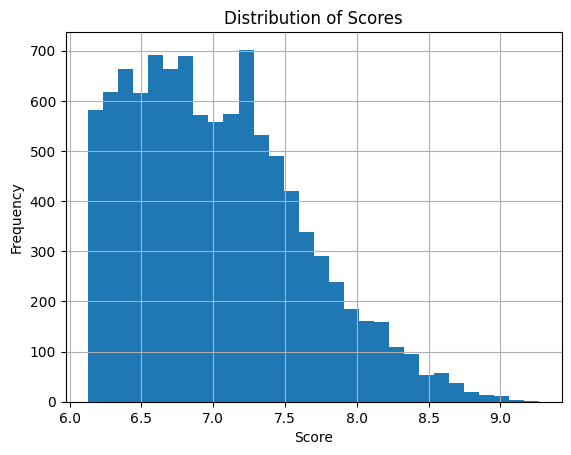

In [ ]:
df['score'].hist(bins=30)
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

Distribution of duration. Most of the dataset has

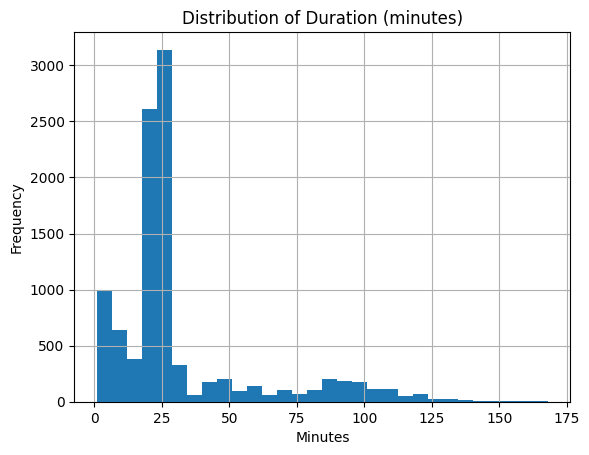

In [ ]:
df['duration_min'].hist(bins=30)
plt.title('Distribution of Duration (minutes)')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.show()

Comparision of the Top ten genres in our dataset

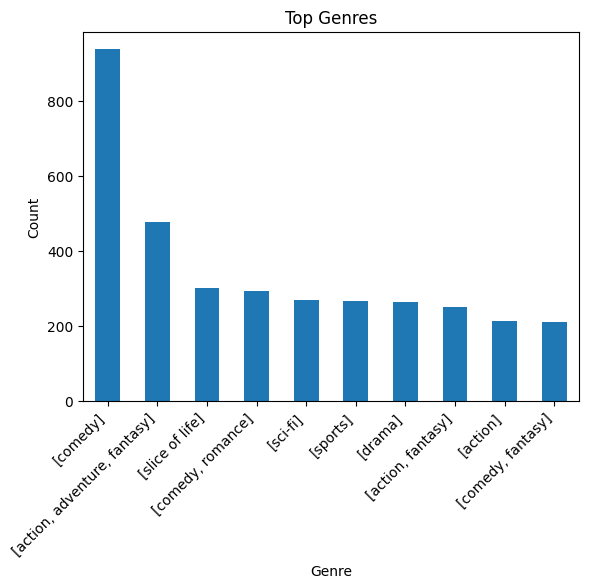

In [ ]:
df['genres'].value_counts().head(10).plot(kind='bar')
plt.title('Top Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha="right")
plt.show()

Correlation Matrix of our numeric columns

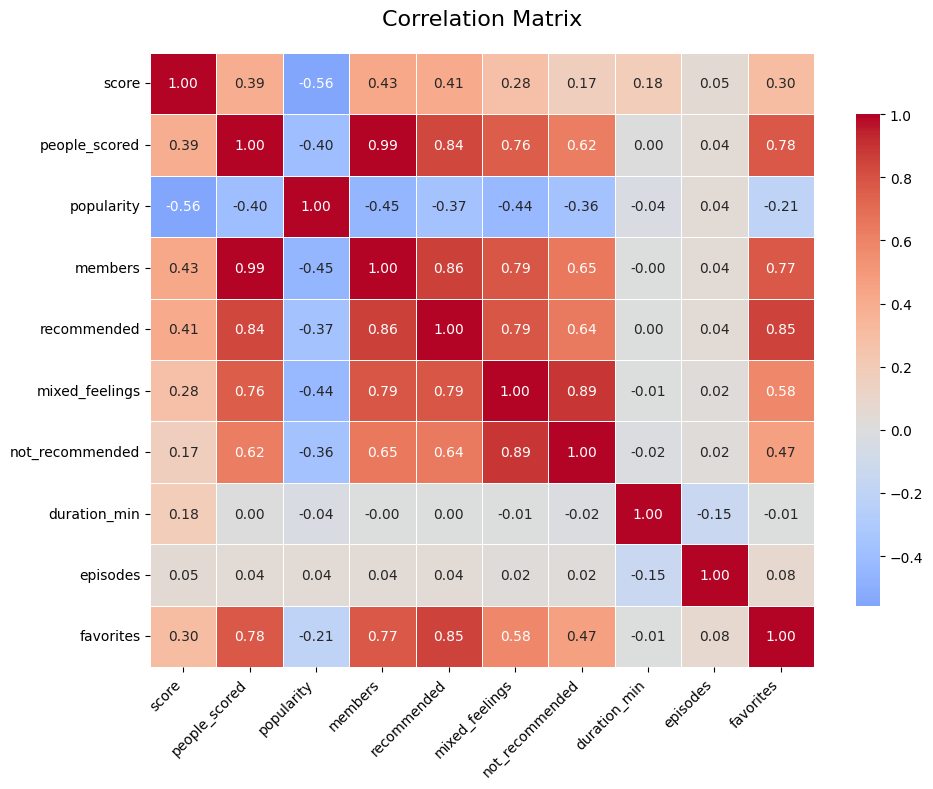

In [ ]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualization

In [ ]:
from matplotlib import pyplot  as plt
import seaborn
import plotly.express as px
import plotly.graph_objects as go

1. Most Productive Studio!

In [ ]:
stud_animes = df[['title', 'studio']].explode('studio')
print(stud_animes.duplicated(subset = 'title').sum())

950


In [ ]:
table = stud_animes.groupby('studio')['title'].count().sort_values(ascending=False).head(10)

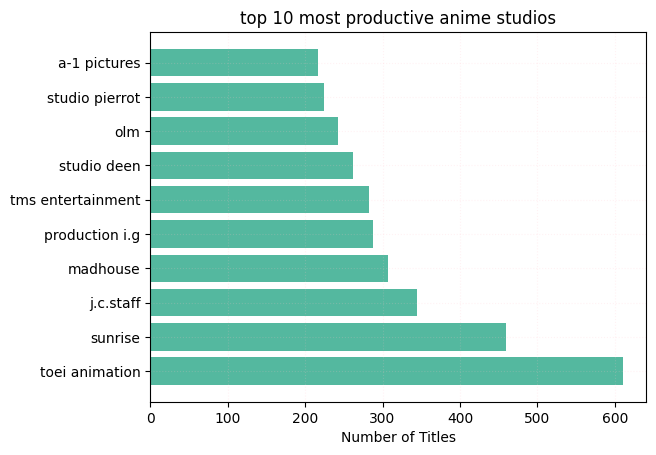

In [ ]:
plt.title('top 10 most productive anime studios')
plt.barh(table.index, table.values, alpha = 0.8, color = '#29A687')
plt.xlabel('Number of Titles')
plt.grid(linestyle = ':', alpha = 0.2, color = 'pink')
plt.show()

2. Old Anime vs New Anime, Popularity vs Score

This visualization shows the classic debate between old-school anime fans and people who think newer anime is better, focusing on 2000s vs post-2015 titles.

In [ ]:
comparison_set = df[['title', 'score', 'popularity', 'start_date']].copy()
comparison_set['type'] = np.where(comparison_set['start_date'] >= '2015-01-01', 'New', 'Old')
comparison_set = comparison_set[comparison_set['start_date'] >= '2000-01-01']

In [ ]:
print(comparison_set.popularity.max())
print(comparison_set.popularity.min())

21828
1


In [ ]:
comparison_set['score_bins'] = pd.cut(comparison_set['score'], bins=[i+1 for i in range(10)], labels=[f'{i+1} - {i +2 }' for i in range(9)])
comparison_set['popularity_bins'] = pd.cut(comparison_set['popularity'], bins=3 , labels=['Very Popular', 'Known', 'Niche' ])

In [ ]:
print(comparison_set)

                                              title  score  popularity  \
0                                 sousou no frieren   9.27         104   
1          steel ball run: jojo no kimyou na bouken   9.16        1447   
2                  fullmetal alchemist: brotherhood   9.11           3   
3                      chainsaw man movie: reze-hen   9.09         589   
4                                       steins;gate   9.07          14   
...                                             ...    ...         ...   
10136  neet kunoichi to nazeka dousei hajimemashita   6.13        3385   
10137                 neko neko nihonshi 2nd season   6.13       15277   
10139                                number24 recap   6.13       11317   
10140                         onikiri musume saisen   6.13       15354   
10141                       osomatsu-san 4th season   6.13        8492   

      start_date type score_bins popularity_bins  
0     2023-09-29  New     9 - 10    Very Popular  
1     202

In [ ]:
comparison_set['score_bins'] = comparison_set['score_bins'].cat.remove_unused_categories()

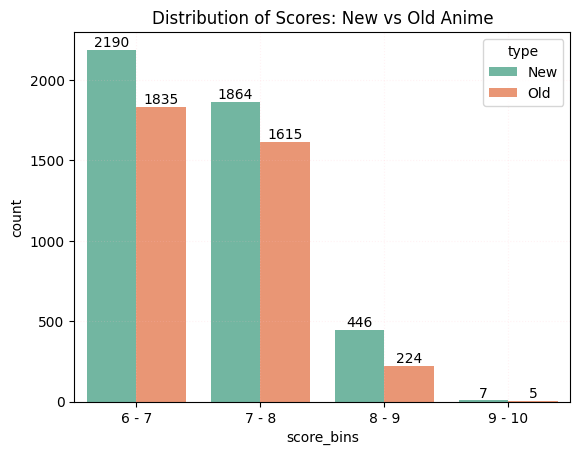

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig = sns.countplot(data=comparison_set, x='score_bins', hue='type', palette = 'Set2')
for container in fig.containers:
    fig.bar_label(container)

plt.grid(linestyle=':', alpha=0.2, color='pink')
plt.title('Distribution of Scores: New vs Old Anime')
plt.show()

From this bar chart we can see that generally new animes dominate the dataset, since in every category number of news is greater than that of oldies.

However, old animes are still takes up plenty place in the dataset, so it will be fair to compare them.

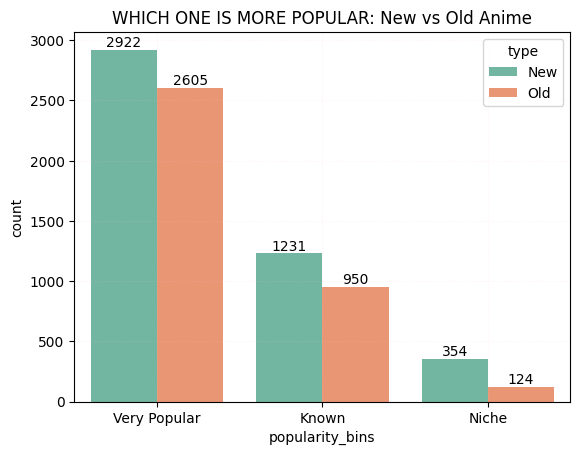

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig = sns.countplot(data=comparison_set, x='popularity_bins', hue='type', palette = 'Set2')
for container in fig.containers:
    fig.bar_label(container)

plt.grid(linestyle=':', alpha=0.2, color='pink')
plt.title('WHICH ONE IS MORE POPULAR: New vs Old Anime')
plt.show()

There are more "New" anime titles (green) than "Old" ones (orange) in every single category. This suggests that the modern era simply produces a higher volume of anime that enters these popularity tiers.

The most striking takeaway is that both New and Old anime are heavily concentrated in the "Very Popular" bin.

Unlike many industries where old content fades into "Niche" status, old anime holds its ground well here (2,619 titles).

As you move from Very Popular → Known → Niche, the gap between New and Old anime widens in terms of ratio:

Very Popular: New is about 1.1x the amount of Old.

Known: New is about 1.27x the amount of Old.

Niche: New is about 2.4x the amount of Old.

Old anime that aren't "Very Popular" or "Known" seem to disappear from the conversation (or the dataset). "Niche" status is dominated by newer titles—likely because older niche titles eventually fall into obscurity and aren't tracked as often, whereas new niche titles are still "fresh" enough to be recorded.

In [ ]:
scores = comparison_set.groupby('type')['score'].mean()
pop = comparison_set.groupby('type')['popularity'].mean()

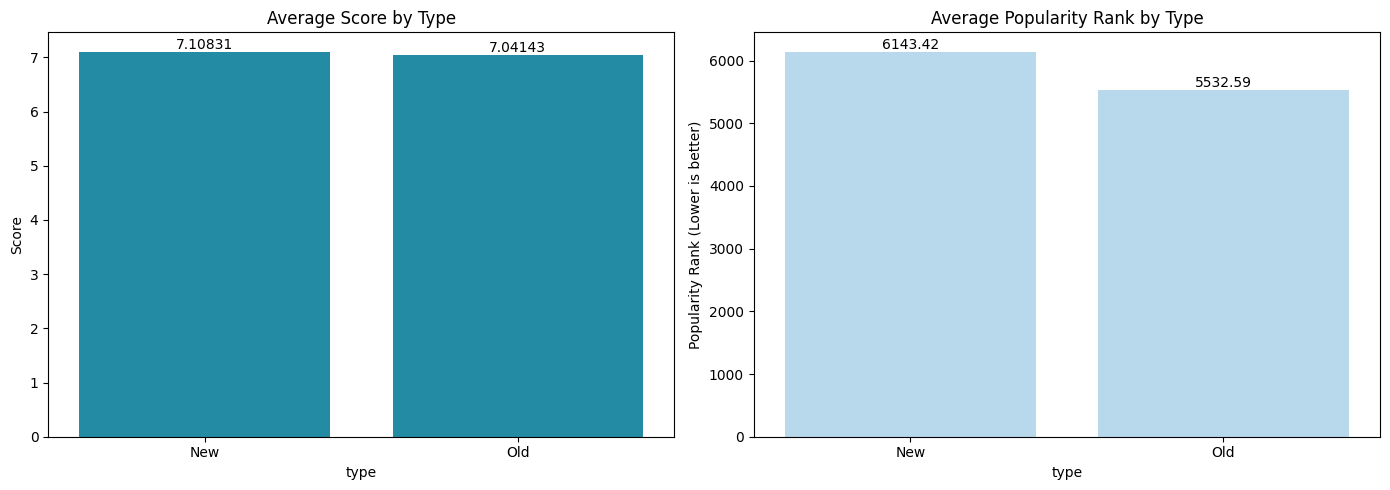

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=scores.index, y=scores.values, ax=ax1, color = '#0d98ba')
ax1.set_title('Average Score by Type')
ax1.set_ylabel('Score')

sns.barplot(x=pop.index, y=pop.values, ax=ax2, color='#afdbf5')
ax2.set_title('Average Popularity Rank by Type')
ax2.set_ylabel('Popularity Rank (Lower is better)')

for container in ax1.containers:
    ax1.bar_label(container)

for container in ax2.containers:
    ax2.bar_label(container)

plt.tight_layout()
plt.show()


It seems that there is no siginificant difference between scores New and Old animes get on average, with difference of mere 0.07. However, old animes seem to be ranked higher on popularity matters.

3. Are Some Anime Seasons Better Than Other?

In [ ]:
table = df.groupby('season')['score'].mean()
table = pd.DataFrame(table)
table = table.reset_index()
print(table)

          season     score
0      fall 1962  6.530000
1      fall 1963  6.550000
2      fall 1964  6.250000
3      fall 1965  6.680000
4      fall 1966  6.510000
..           ...       ...
248  winter 2022  7.070698
249  winter 2023  7.159669
250  winter 2024  7.146354
251  winter 2025  7.169419
252  winter 2026  7.237600

[253 rows x 2 columns]


In [ ]:
def season_to_num(series):
  s = series.split(' ')
  if s[0] == 'winter':
    rank = 1
  elif s[0] == 'spring':
    rank = 2
  elif s[0] == 'summer':
    rank = 3
  elif s[0] == 'fall':
    rank = 4

  return f'{s[1]} + {rank}'

In [ ]:
table['season_for_sort'] = table['season'].apply(season_to_num)
table.sort_values(by='season_for_sort', inplace=True)
print(table)

          season     score season_for_sort
127  summer 1956  6.470000        1956 + 3
64   spring 1959  6.140000        1959 + 2
128  summer 1960  6.200000        1960 + 3
129  summer 1961  6.330000        1961 + 3
0      fall 1962  6.530000        1962 + 4
..           ...       ...             ...
125  spring 2025  7.119785        2025 + 2
189  summer 2025  7.206296        2025 + 3
63     fall 2025  7.171461        2025 + 4
252  winter 2026  7.237600        2026 + 1
126  spring 2026  7.271270        2026 + 2

[253 rows x 3 columns]


In [ ]:
print(df['season'].value_counts())

season
fall 2023      133
winter 2023    121
summer 2024    119
spring 2018    118
fall 2024      115
              ... 
summer 1961      1
fall 1964        1
summer 1960      1
winter 1970      1
spring 1959      1
Name: count, Length: 253, dtype: int64


In [ ]:
table['year_time'] = table['season'].apply(lambda x: x.split(' ')[0])
print(table)

          season     score season_for_sort year_time
127  summer 1956  6.470000        1956 + 3    summer
64   spring 1959  6.140000        1959 + 2    spring
128  summer 1960  6.200000        1960 + 3    summer
129  summer 1961  6.330000        1961 + 3    summer
0      fall 1962  6.530000        1962 + 4      fall
..           ...       ...             ...       ...
125  spring 2025  7.119785        2025 + 2    spring
189  summer 2025  7.206296        2025 + 3    summer
63     fall 2025  7.171461        2025 + 4      fall
252  winter 2026  7.237600        2026 + 1    winter
126  spring 2026  7.271270        2026 + 2    spring

[253 rows x 4 columns]


In [ ]:
fig = px.line(table, x='season', y='score',  markers=True)
fig.update_traces(line=dict(color='DarkSlateGrey'))

fig.update_traces(
    line=dict(width=1, shape='spline')
)

color_map = {
    'winter': '#1f77b4', # Blue
    'spring': '#2ca02c', # Green
    'summer': '#ff7f0e', # Orange
    'fall': '#d62728'    # Red
}

fig.update_traces(marker=dict(
    color=[color_map[val] for val in table['year_time']],
    size=6,
    symbol = 'diamond'
))
for season, color in color_map.items():
    fig.add_trace(go.Scatter(
        x=[None], y=[None], # No data, just for legend
        mode='markers',
        marker=dict(size=10, color=color),
        name=season.capitalize()
    ))

fig.show()

Across whole plot, we can see that average rating of spring and fall seasons tend to be slightly higher, than that of summer and winter season since orange and blue often falls lower. However, trend is experiencing some changes last years.

In [ ]:
print(table.groupby('year_time')['score'].mean().sort_values())

year_time
summer    6.820651
spring    6.930613
fall      6.939289
winter    6.951303
Name: score, dtype: float64


4. Popularity vs. Score (The "Under-Hyped" Analysis)

In [ ]:
from sklearn.preprocessing import MinMaxScaler


scatter_setup = df[['english_title', 'score', 'popularity']].copy()
scatter_setup = scatter_setup.dropna()

scaler = MinMaxScaler()
scatter_setup['popularity'] = 1- scaler.fit_transform(scatter_setup[['popularity']])

In [ ]:
fig = px.scatter(scatter_setup, x = 'popularity', y = 'score', hover_data='english_title', title = 'Anime Titles: Popularity vs Score. Hidden Gems?')
fig.update_traces(marker=dict(
    size=6,
    symbol = 'diamond', opacity = 0.5
))
fig.show()

On the right side of the plot, we see a vertical explosion of blue diamonds. This is the Mainstream. These are the shows that everyone talks about—the One Pieces, Attack on Titans, and Demon Slayers.

Notice how the scores here are generally higher and more "packed" together.

Popularity breeds a certain level of quality (or at least high production value). Once a show hits a certain level of fame, it becomes a cultural event, and the community consensus usually settles into a high score.

Mediocre animes are mostly pooled in the bottom center. However if we look up the score line, we will be able to see hidden gems. The left side of the bar contains low-scoring animes that seems to be equally unpopular. I've noticed that hidden gems mostly contains names of chineese 3d animation. Whereas most hold predjuce regarding them, these title seems to be well-loved by genre fans.

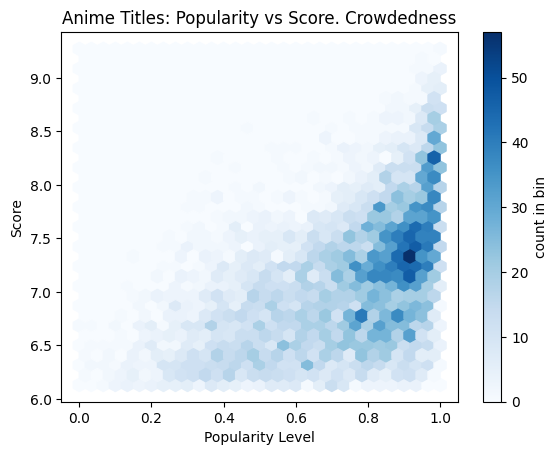

In [ ]:
plt.hexbin(scatter_setup['popularity'], scatter_setup['score'], gridsize=30, cmap='Blues')
plt.title ( 'Anime Titles: Popularity vs Score. Crowdedness')
plt.colorbar(label='count in bin')
plt.xlabel('Popularity Level')
plt.ylabel('Score')
plt.show()

Here we might notice that generally animes evenly crowd each category safe for popular animes with average score. The darkest point of the plot is here which might spotlight tendency of title scores getting lower the more popular it gets.

5. Animation Plot of Studios and Their Average Scores-Popularity Over Years

In [ ]:
df.head()

,title,score,people_scored,popularity,members,season,studio,description,recommended,mixed_feelings,not_recommended,rec,mix,not_rec,english_title,show_type,status,broadcast,producers,licensors,source,genres,duration_min,episodes,rating,themes,demographics,favorites,broadcast_day,broadcast_time,start_date,end_date
0,sousou no frieren,9.27,869731,104,1411377,fall 2023,[madhouse],during their decade-long quest to defeat the d...,819,144,116,i feel so catered to.\r\n\r\nit feels like an ...,someone recommended me to watch this title las...,style-\r\nfrieren doesn't have its own unique ...,frieren: beyond journey's end,tv,finished airing,fridays at 23:00 (jst),"[aniplex, dentsu, shogakukan-shueisha producti...",[crunchyroll],manga,"[adventure, award winning, drama, fantasy]",24.0,28.0,pg-13 - teens 13 or older,NaN,[shounen],88070,Friday,23:00:00,2023-09-29,2024-03-22
1,steel ball run: jojo no kimyou na bouken,9.16,86411,1447,189929,spring 2026,[david production],"in the american old west, the world's greatest...",156,7,1,i watched the first episode and it was truly a...,i will summarize it for you in two words.\r\nn...,the part 7 adaption is similar to its previous...,steel ball run: jojo's bizarre adventure,ona,currently airing,NaN,"[warner bros. japan, studio mausu, onemusic]",NaN,manga,"[action, adventure, mystery, supernatural]",47.0,NaN,r - 17+ (violence & profanity),"[historical, racing]","[seinen, shounen]",6051,NaN,NaT,2026-03-19,NaT
2,fullmetal alchemist: brotherhood,9.11,2303444,3,3667785,spring 2009,[bones],after a horrific alchemy experiment goes wrong...,971,69,44,"first of all, i have seen the original fma and...",fullmetal alchemist: brotherhood gets an immen...,*spoiler warning\r\n\r\naside from the usual e...,fullmetal alchemist: brotherhood,tv,finished airing,sundays at 17:00 (jst),"[aniplex, square enix, mainichi broadcasting s...","[funimation, aniplex of america]",manga,"[action, adventure, drama, fantasy]",24.0,64.0,r - 17+ (violence & profanity),[military],[shounen],241796,Sunday,17:00:00,2009-04-05,2010-07-04
3,chainsaw man movie: reze-hen,9.09,282353,589,449212,fall 2025,[mappa],despite the immediate challenges following bec...,322,46,19,in short if you like and read the chainsaw man...,quick little review because i feel my perspect...,writing this review to compile my thoughts on ...,chainsaw man – the movie: reze arc,movie,finished airing,NaN,NaN,NaN,manga,"[action, fantasy]",99.0,1.0,r - 17+ (violence & profanity),"[gore, urban fantasy]",[shounen],12951,NaN,NaT,2025-09-19,NaT
4,steins;gate,9.07,1516022,14,2802086,spring 2011,[white fox],eccentric scientist rintarou okabe has a never...,1075,88,84,“no one knows what the future holds. that’s wh...,one word: hype.\r\n\r\nbefore watching this sh...,just a horrible anime. this is the anime equiv...,steins;gate,tv,finished airing,wednesdays at 02:05 (jst),"[frontier works, media factory, kadokawa shote...",[funimation],visual novel,"[drama, sci-fi, suspense]",24.0,24.0,pg-13 - teens 13 or older,"[psychological, time travel]",NaN,201780,Wednesday,02:05:00,2011-04-06,2011-09-14


In [ ]:
setting = df[['studio', 'score', 'popularity', 'season']].copy()

In [ ]:
setting = setting.dropna()
setting['year'] = setting['season'].apply(lambda x: x.split(' ')[1])
setting['year'] = pd.to_datetime(setting['year'], format='%Y', errors ='coerce')

In [ ]:
setting = setting.explode('studio')
print(setting)

                 studio  score  popularity       season       year
0              madhouse   9.27         104    fall 2023 2023-01-01
1      david production   9.16        1447  spring 2026 2026-01-01
2                 bones   9.11           3  spring 2009 2009-01-01
3                 mappa   9.09         589    fall 2025 2025-01-01
4             white fox   9.07          14  spring 2011 2011-01-01
...                 ...    ...         ...          ...        ...
10136              quad   6.13        3385  winter 2025 2025-01-01
10137       joker films   6.13       15277  spring 2017 2017-01-01
10138    studio pierrot   6.13       12374  summer 1995 1995-01-01
10139               pra   6.13       11317  spring 2020 2020-01-01
10141     pierrot films   6.13        8492  summer 2025 2025-01-01

[10596 rows x 5 columns]


In [ ]:
setting = setting.groupby(['studio', 'year'])[['score', 'popularity']].mean().reset_index()
print(setting)

         studio       year     score  popularity
0     100studio 2024-01-01  6.895000      5764.0
1     100studio 2025-01-01  7.156667      7610.0
2       10gauge 2014-01-01  6.690000     11568.0
3       10gauge 2015-01-01  6.930000     12289.0
4       10gauge 2016-01-01  6.490000      8555.0
...         ...        ...       ...         ...
3975      zexcs 2024-01-01  6.960000     11610.0
3976      zexcs 2025-01-01  8.070000      2713.0
3977      zexcs 2026-01-01  8.060000      4082.0
3978      zuiyo 2000-01-01  7.300000      6478.0
3979      zuiyo 2002-01-01  6.170000     14572.0

[3980 rows x 4 columns]


In [ ]:
setting['popularity'] = 1 - scaler.fit_transform(setting[['popularity']])

In [ ]:
setting.groupby('studio')['year'].count().reset_index().sort_values(by = 'year').tail(15)['studio']

,studio
203,gallop
548,studio comet
655,tokyo movie shinsha
641,tezuka productions
446,production i.g
271,j.c.staff
552,studio deen
598,studio pierrot
384,nippon animation
647,tms entertainment


In [ ]:
setting = setting[setting['studio'].isin(setting.groupby('studio')['year'].count().reset_index().sort_values(by = 'year').tail(15)['studio'])]

In [ ]:
setting = setting.sort_values(by = 'year')
print(setting)

                    studio       year     score  popularity
3484        toei animation 1959-01-01  6.140000    0.428815
3485        toei animation 1960-01-01  6.200000    0.515004
3486        toei animation 1961-01-01  6.330000    0.482582
3487        toei animation 1963-01-01  6.590000    0.519500
3572   tokyo movie shinsha 1964-01-01  6.720000    0.393080
...                    ...        ...       ...         ...
3311  tatsunoko production 2026-01-01  6.620000    0.683075
2876           studio deen 2026-01-01  7.096667    0.736826
3464     tms entertainment 2026-01-01  7.222000    0.791272
3549        toei animation 2026-01-01  7.540000    0.540752
3100        studio pierrot 2026-01-01  6.620000    0.539284

[665 rows x 4 columns]


In [ ]:
setting['year_int'] = pd.to_datetime(setting['year']).dt.year

all_years = np.arange(setting['year_int'].min(), setting['year_int'].max() + 1)
all_studios = setting['studio'].unique()

full_index = pd.MultiIndex.from_product([all_studios, all_years], names=['studio', 'year_int'])
full_df = pd.DataFrame(index=full_index).reset_index()

animated_df = pd.merge(full_df, setting, on=['studio', 'year_int'], how='left')

In [ ]:
animated_df = animated_df.sort_values(['studio', 'year_int'])
animated_df[['score', 'popularity']] = animated_df.groupby('studio')[['score', 'popularity']].ffill()
animated_df['year'] = animated_df['year'].fillna(1959)
animated_df = animated_df.fillna(0)
animated_df = animated_df.sort_values(by = 'year_int')
print(animated_df)

                  studio  year_int                 year     score  popularity
748               gallop      1959                 1959  0.000000    0.000000
680          studio deen      1959                 1959  0.000000    0.000000
136    shin-ei animation      1959                 1959  0.000000    0.000000
952       production i.g      1959                 1959  0.000000    0.000000
272    tms entertainment      1959                 1959  0.000000    0.000000
..                   ...       ...                  ...       ...         ...
67        toei animation      2026  2026-01-01 00:00:00  7.540000    0.540752
475             madhouse      2026  2026-01-01 00:00:00  7.610000    0.833980
543              sunrise      2026  2026-01-01 00:00:00  7.033333    0.687177
951            j.c.staff      2026  2026-01-01 00:00:00  7.890000    0.872823
135  tokyo movie shinsha      2026                 1959  6.190000    0.398145

[1020 rows x 5 columns]


In [ ]:
fig = px.scatter(animated_df, x="popularity", y="score", animation_frame="year_int", animation_group="studio",
           size="popularity", color="studio",
           log_x=True, size_max=20, range_x=[0.1, 1.1], range_y=[5, 10], title = "15 most consistent studios's scores and popularity over years")
fig.show()

From this animation plot we can see how the number of anime-studios increased over years from 1959 to current days. Chaotic movement of scatters suggests that every studio experieced their downs and rises over time, and their general popularity levels actually grew but average score levels did not experiece neither dramatic increase nor decrease over years. In early 2000-s tokyo movie shinsha was the most high-scoring animation studio, however in 2026 their averege score stands out as lowest of all (after their 2014 Magic Knight Rayearth Pilot Maho-Shoujo).

6. Which Studios Target Which Demographics?

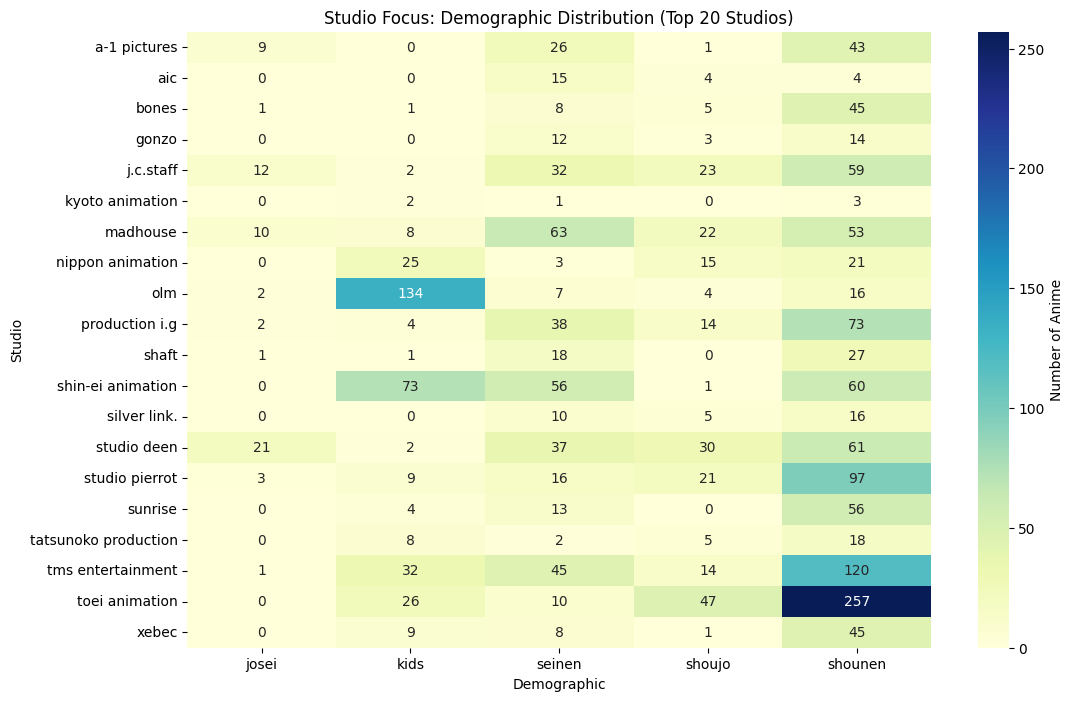

In [ ]:
top_studios_list = df['studio'].explode().value_counts().nlargest(20).index.tolist()

exploded_df = df.explode('studio')
exploded_df = exploded_df[exploded_df['studio'].isin(top_studios_list)]
exploded_df = exploded_df.explode('demographics')
exploded_df = exploded_df[exploded_df['demographics'].notna()]

pivot_table = pd.crosstab(exploded_df['studio'], exploded_df['demographics'])

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Number of Anime'})

plt.title('Studio Focus: Demographic Distribution (Top 20 Studios)')
plt.xlabel('Demographic')
plt.ylabel('Studio')
plt.show()

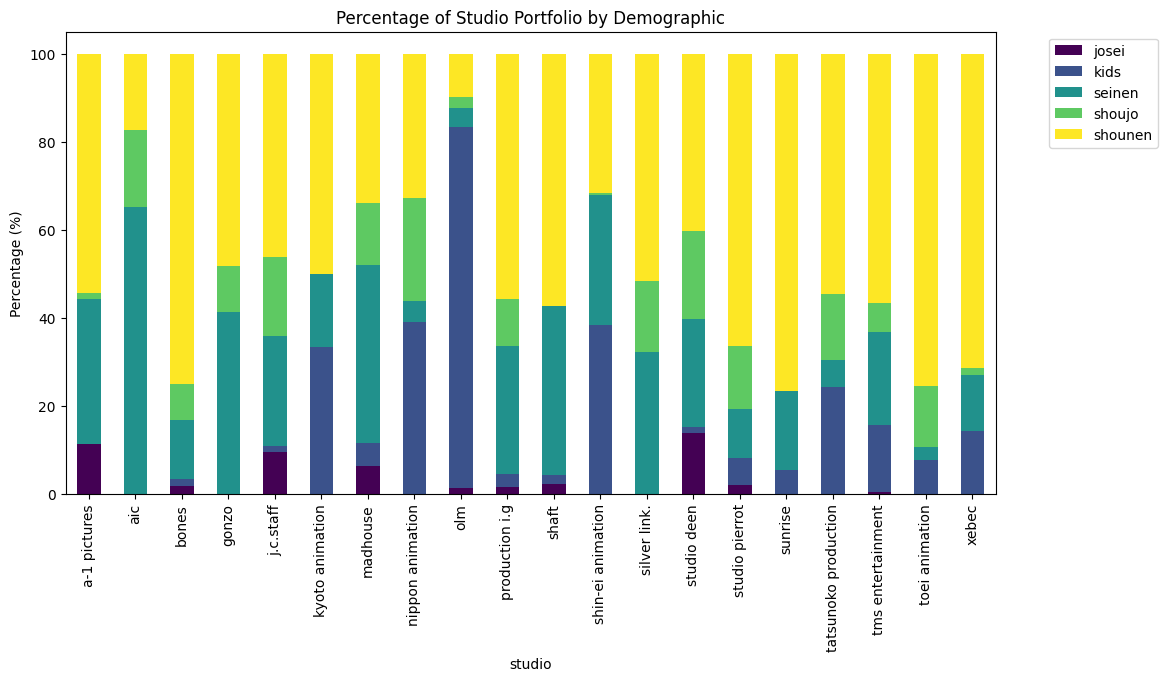

In [ ]:
pivot_perc = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

pivot_perc.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Percentage of Studio Portfolio by Demographic')
plt.ylabel('Percentage (%)')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

7. Duration vs Popularity, what is happenning to attention

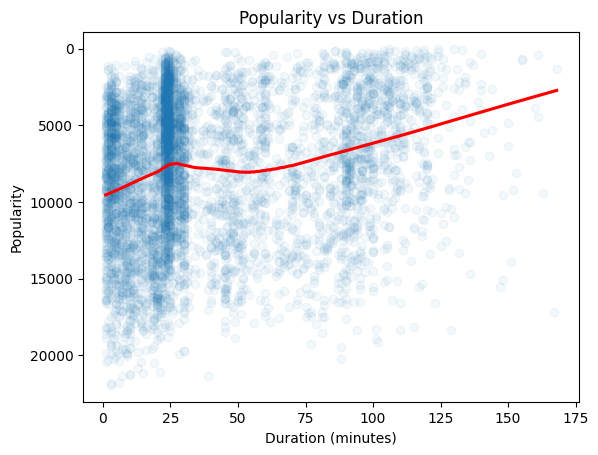

In [ ]:
subset = df[df['show_type'] != 'tv']
sns.regplot(data=subset, x='duration_min', y='popularity',
            scatter_kws={'alpha': 0.05}, line_kws={'color':'r'},
            lowess=True)
plt.gca().invert_yaxis()
plt.title('Popularity vs Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity')
plt.show()

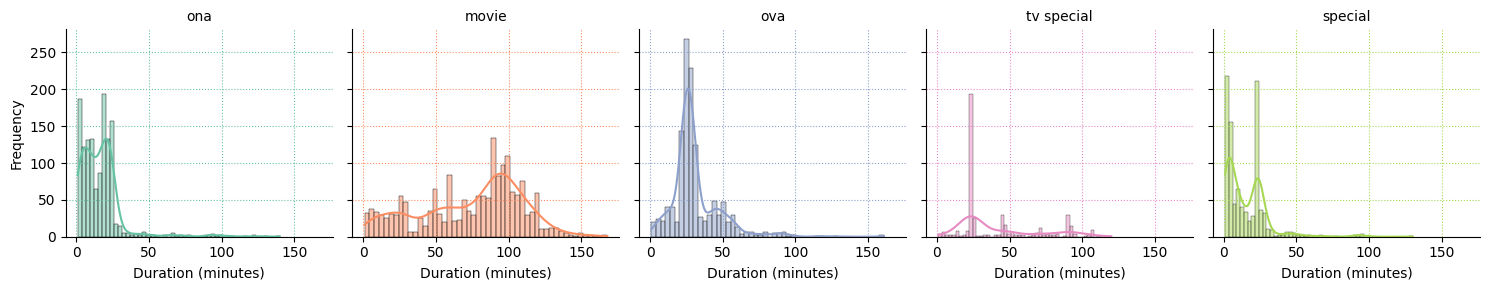

In [ ]:
g = sns.FacetGrid(subset, col='show_type', col_wrap=5, hue = 'show_type', palette = 'Set2')
g.map(sns.histplot, 'duration_min', bins=50, kde = True)
g.map(plt.grid, linestyle = ':')
g.set_axis_labels('Duration (minutes)', 'Frequency')
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

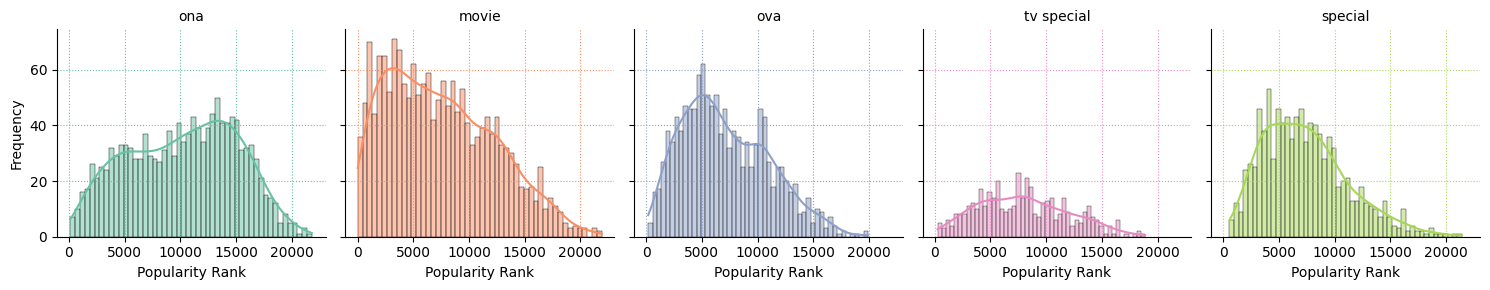

In [ ]:
g = sns.FacetGrid(subset, col='show_type', col_wrap=5, hue = 'show_type', palette = 'Set2')
g.map(sns.histplot, 'popularity', bins=50, kde = True, )
g.map(plt.grid, linestyle = ':')
g.set_axis_labels('Popularity Rank', 'Frequency')
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

In [ ]:
data = df.groupby('show_type')['popularity'].mean().reset_index()

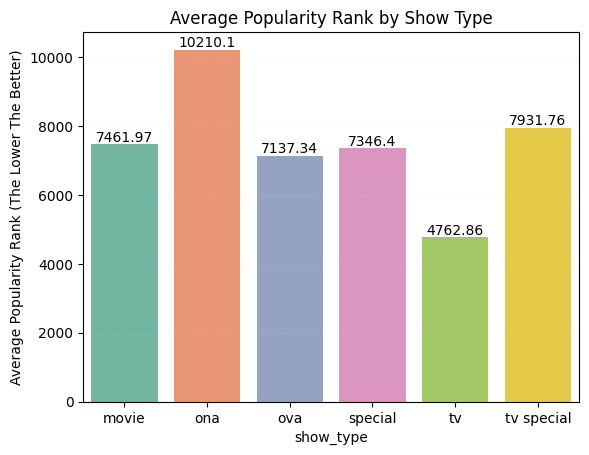

In [ ]:
plt.grid(linestyle=':', alpha=0.2, color='pink')
fig = sns.barplot(data=data, x='show_type', y='popularity',  hue='show_type', palette = 'Set2')
for container in fig.containers:
    plt.bar_label(container)
plt.title('Average Popularity Rank by Show Type')
plt.ylabel('Average Popularity Rank (The Lower The Better)')
plt.show()

8. Scores vs Duration

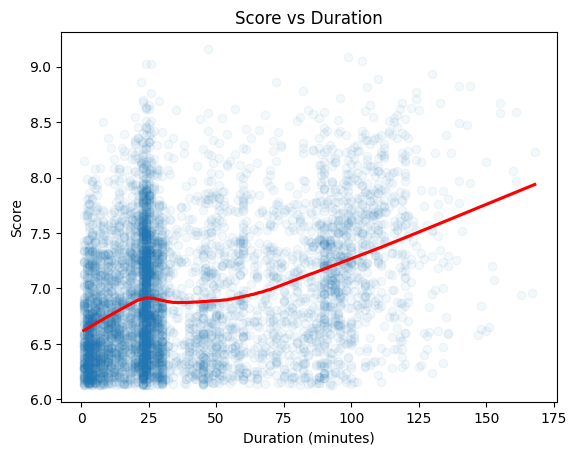

In [ ]:
subset = df[df['show_type'] != 'tv']
sns.regplot(data=subset, x='duration_min', y='score',
            scatter_kws={'alpha': 0.05}, line_kws={'color':'r'},
            lowess=True)
plt.title('Score vs Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Score')
plt.show()

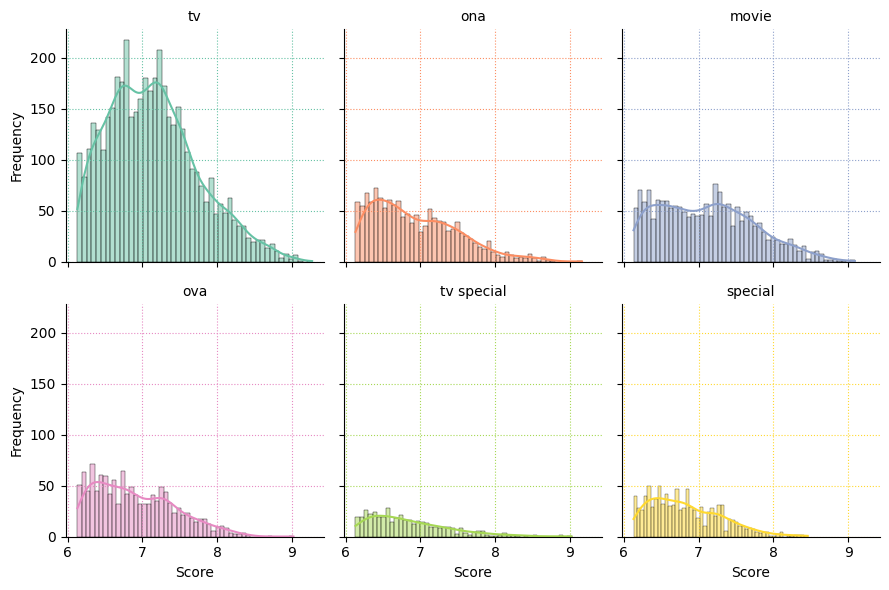

In [ ]:
g = sns.FacetGrid(df, col='show_type', col_wrap=3, hue = 'show_type', palette = 'Set2')
g.map(sns.histplot, 'score', bins=50, kde = True)
g.map(plt.grid, linestyle = ':')
g.set_axis_labels('Score', 'Frequency')
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

In [ ]:
data = df.groupby('show_type')['score'].mean().reset_index()

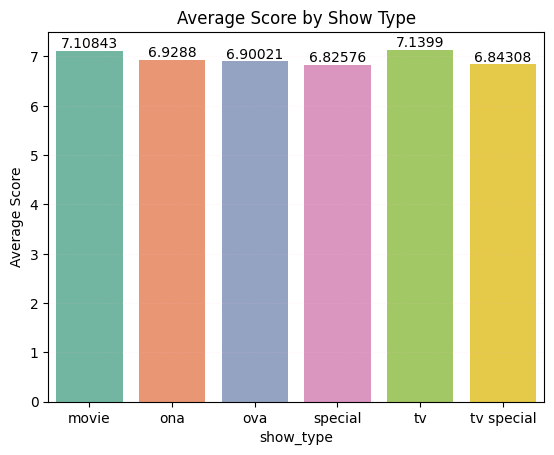

In [ ]:
plt.grid(linestyle=':', alpha=0.2, color='pink')
fig = sns.barplot(data=data, x='show_type', y='score',  hue='show_type', palette = 'Set2')
for container in fig.containers:
    plt.bar_label(container)
plt.title('Average Score by Show Type')
plt.ylabel('Average Score')
plt.show()

9. Rating vs Broadcast Time: When Violence Takes Peak

In [ ]:
comparison_set = df[['broadcast_time', 'rating']].copy()
comparison_set = comparison_set.dropna()
comparison_set['broadcast_time_seconds'] = comparison_set['broadcast_time'].apply(lambda t: t.hour * 3600 + t.minute * 60 + t.second)
comparison_set['broadcast_bins'] = pd.cut(
    comparison_set['broadcast_time_seconds'],
    bins=4,
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)
print(comparison_set.sample(10))

     broadcast_time                          rating  broadcast_time_seconds  \
7261       22:30:00       pg-13 - teens 13 or older                   81000   
5801       00:30:00       pg-13 - teens 13 or older                    1800   
6363       18:15:00                    g - all ages                   65700   
433        22:30:00  r - 17+ (violence & profanity)                   81000   
146        00:30:00       pg-13 - teens 13 or older                    1800   
662        07:00:00       pg-13 - teens 13 or older                   25200   
1374       01:30:00       pg-13 - teens 13 or older                    5400   
5150       02:00:00       pg-13 - teens 13 or older                    7200   
681        18:15:00       pg-13 - teens 13 or older                   65700   
8338       10:00:00                r+ - mild nudity                   36000   

     broadcast_bins  
7261        Evening  
5801          Night  
6363        Evening  
433         Evening  
146           Night 

In [ ]:
pivot = pd.crosstab(comparison_set['broadcast_bins'], comparison_set['rating'])
print(pivot)

rating          g - all ages  pg - children  pg-13 - teens 13 or older  \
broadcast_bins                                                           
Night                     34              9                       1185   
Morning                   78             69                        115   
Afternoon                 23             17                        132   
Evening                  192             87                       1003   

rating          r - 17+ (violence & profanity)  r+ - mild nudity  
broadcast_bins                                                    
Night                                      317                93  
Morning                                      5                20  
Afternoon                                   15                 2  
Evening                                    203                59  


In [ ]:
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0)
print(pivot_percent.T)

broadcast_bins                     Night   Morning  Afternoon   Evening
rating                                                                 
g - all ages                    0.020757  0.271777   0.121693  0.124352
pg - children                   0.005495  0.240418   0.089947  0.056347
pg-13 - teens 13 or older       0.723443  0.400697   0.698413  0.649611
r - 17+ (violence & profanity)  0.193529  0.017422   0.079365  0.131477
r+ - mild nudity                0.056777  0.069686   0.010582  0.038212


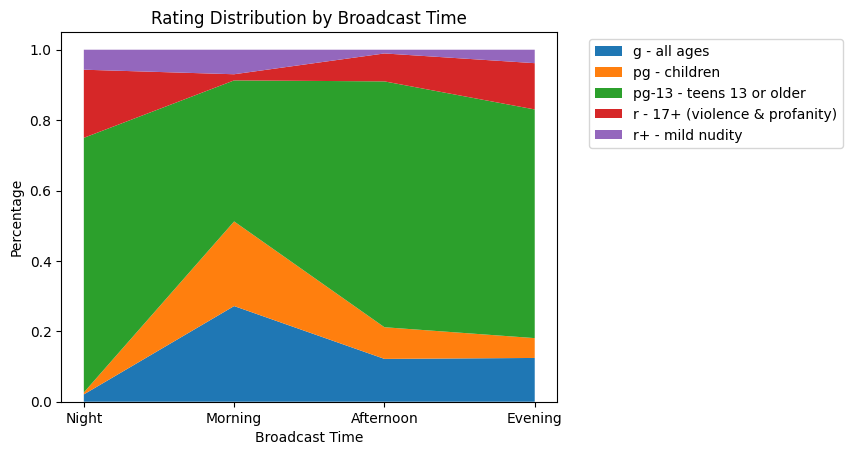

In [ ]:
plt.stackplot(pivot_percent.index, pivot_percent.T, labels=pivot_percent.columns)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.title('Rating Distribution by Broadcast Time')
plt.xlabel('Broadcast Time')
plt.ylabel('Percentage')
plt.show()

Actually, violence never seems to take peak, however there is considerably less amount of it mornings. According to known information, the widly broadcasted rating is pg-13, which is quite kid and teen friendly. Japaneese parents can turn on TV without unnecessary worrying.

10. Does Particular Broadcasting Weekdays(ends) Make Anime More Popular?

In [ ]:
df.columns

Index(['title', 'score', 'people_scored', 'popularity', 'members', 'season',
       'studio', 'description', 'recommended', 'mixed_feelings',
       'not_recommended', 'rec', 'mix', 'not_rec', 'english_title',
       'show_type', 'status', 'broadcast', 'producers', 'licensors', 'source',
       'genres', 'duration_min', 'episodes', 'rating', 'themes',
       'demographics', 'favorites', 'broadcast_day', 'broadcast_time',
       'start_date', 'end_date'],
      dtype='object')

In [ ]:
wee = df[['broadcast_day', 'popularity']].copy()

In [ ]:
wee = wee.dropna()
data=wee.groupby('broadcast_day', observed=False)['popularity'].mean().reset_index()
print(data)

  broadcast_day   popularity
0        Monday  3896.428962
1       Tuesday  3899.460280
2     Wednesday  3883.674419
3      Thursday  3608.301587
4        Friday  3390.646281
5      Saturday  3982.145892
6        Sunday  3859.386216


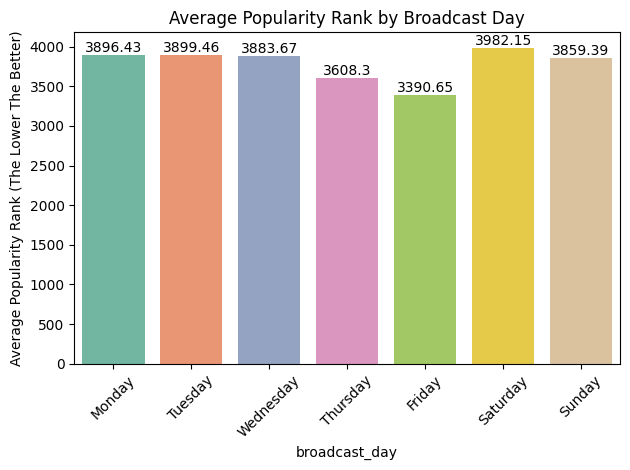

In [ ]:
fig = sns.barplot(data=data, x=data['broadcast_day'], y=data['popularity'], hue='broadcast_day', palette = 'Set2')

for container in fig.containers:
    fig.bar_label(container)

plt.title('Average Popularity Rank by Broadcast Day')
plt.ylabel('Average Popularity Rank (The Lower The Better)')
plt.xticks(ha='center', rotation=45)
plt.tight_layout()
plt.show()

Friday Shows seem to be more popular!

11. *Less scored people leads to higher scores?*

In [ ]:
subset = df[['people_scored', 'score', 'recommended']].copy()

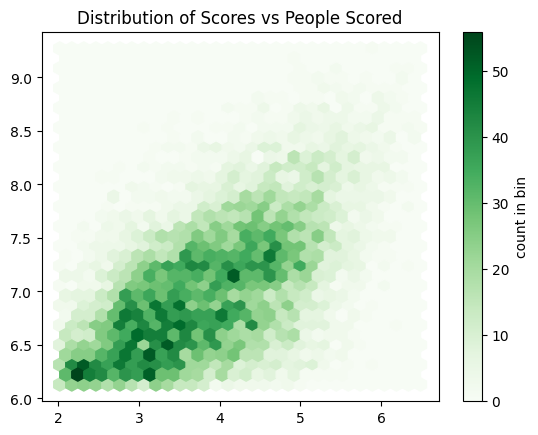

In [ ]:
subset['people_scored_log'] = np.log10(subset['people_scored']+1)
plt.title('Distribution of Scores vs People Scored')
plt.hexbin(data=subset, x='people_scored_log', y='score', gridsize=30, cmap='Greens')
plt.colorbar(label='count in bin')
plt.show()

In [ ]:
subset['rec_log'] = np.log10(subset['recommended']+1)
fig = px.scatter(subset, x='people_scored', y='score', color='rec_log',
                 title='Scores vs People Scored', color_continuous_scale='peach', hover_data='recommended', opacity=0.9)
fig.update_traces(marker=dict(size=6, symbol = 'diamond'))
fig.show()

12. People who favorite anime tend to write recommendation?

In [ ]:
df.columns

Index(['title', 'score', 'people_scored', 'popularity', 'members', 'season',
       'studio', 'description', 'recommended', 'mixed_feelings',
       'not_recommended', 'rec', 'mix', 'not_rec', 'english_title',
       'show_type', 'status', 'broadcast', 'producers', 'licensors', 'source',
       'genres', 'duration_min', 'episodes', 'rating', 'themes',
       'demographics', 'favorites', 'broadcast_day', 'broadcast_time',
       'start_date', 'end_date'],
      dtype='object')

In [ ]:
subset = df[['recommended', 'mixed_feelings', 'not_recommended', 'favorites', 'score']].copy()

In [ ]:
subset['score_bins'] = pd.cut(subset['score'], bins=[i+1 for i in range(10)], labels=[f'{i+1} - {i+2}' for i in range(9)])
subset['score_bins'] = subset['score_bins'].cat.remove_unused_categories()
print(subset.head(10))

   recommended  mixed_feelings  not_recommended  favorites  score score_bins
0          819             144              116      88070   9.27     9 - 10
1          156               7                1       6051   9.16     9 - 10
2          971              69               44     241796   9.11     9 - 10
3          322              46               19      12951   9.09     9 - 10
4         1075              88               84     201780   9.07     9 - 10
5           76               2                4       4653   9.05     9 - 10
6           85               4                1      17485   9.05     9 - 10
7          210              10               10      63033   9.05     9 - 10
8          808              65               56     228489   9.03     9 - 10
9          185              14               10      17777   9.02     9 - 10


In [ ]:
pivot = subset.groupby('score_bins', observed=False)[['recommended', 'mixed_feelings', 'not_recommended']].sum()

In [ ]:
print(pivot)

            recommended  mixed_feelings  not_recommended
score_bins                                              
6 - 7             24191           13817            13341
7 - 8             83391           23939            16507
8 - 9             68333           11047             7362
9 - 10             4854             454              350


In [ ]:
percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
print(percent)

            recommended  mixed_feelings  not_recommended
score_bins                                              
6 - 7         47.110947       26.908022        25.981032
7 - 8         67.339325       19.331056        13.329619
8 - 9         78.777294       12.735468         8.487238
9 - 10        85.790032        8.024037         6.185931


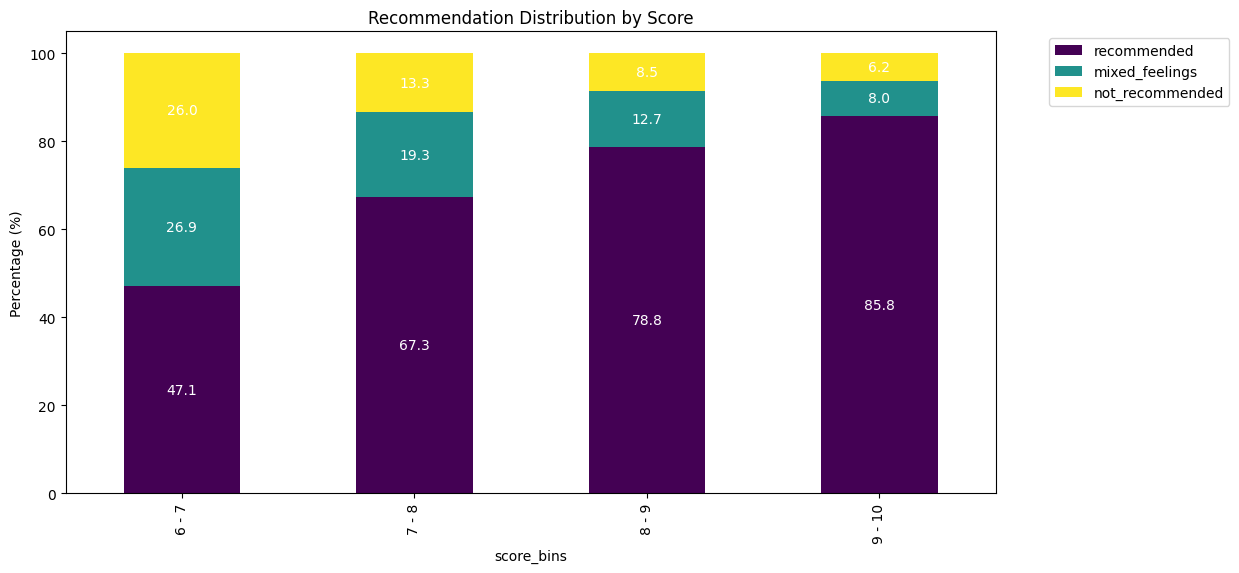

In [ ]:
ax = percent.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
for i, container in enumerate(ax.containers):
    labels = percent.iloc[:, i].round(1)
    ax.bar_label(container, labels=labels, label_type='center', color='white', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.title('Recommendation Distribution by Score')
plt.ylabel('Percentage (%)')
plt.show()

In [ ]:
pivot = pivot.reset_index()

In [ ]:
pivot_melted = pivot.melt(id_vars='score_bins', var_name='Category', value_name='Value')
print(pivot_melted)

   score_bins         Category  Value
0       6 - 7      recommended  24191
1       7 - 8      recommended  83391
2       8 - 9      recommended  68333
3      9 - 10      recommended   4854
4       6 - 7   mixed_feelings  13817
5       7 - 8   mixed_feelings  23939
6       8 - 9   mixed_feelings  11047
7      9 - 10   mixed_feelings    454
8       6 - 7  not_recommended  13341
9       7 - 8  not_recommended  16507
10      8 - 9  not_recommended   7362
11     9 - 10  not_recommended    350


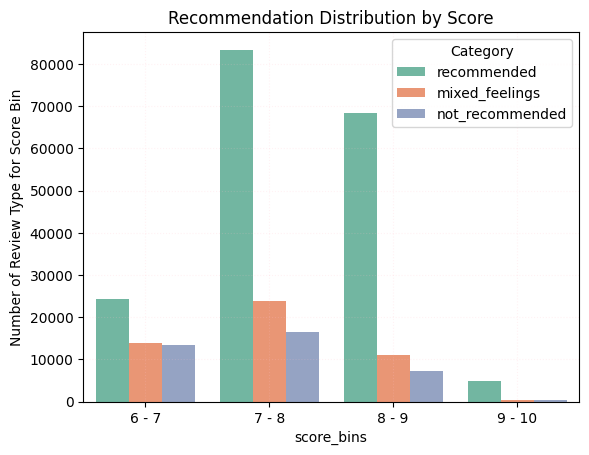

In [ ]:
sns.barplot(data=pivot_melted, x='score_bins', y='Value', hue='Category', palette = 'Set2')
plt.grid(linestyle=':', alpha=0.2, color='pink')
plt.title('Recommendation Distribution by Score')
plt.ylabel('Number of Review Type for Score Bin')
plt.show()

In [ ]:
subset = df[['recommended', 'mixed_feelings', 'not_recommended', 'favorites']].copy()

In [ ]:
subset['fav_level'] = pd.qcut(subset['favorites'], q=3, labels=['Low Favs', 'Medium Favs', 'High Favs'])

melted_subset = subset.melt(
    id_vars=['fav_level'],
    value_vars=['recommended', 'mixed_feelings', 'not_recommended'],
    var_name='Rec_Type',
    value_name='Count'
)


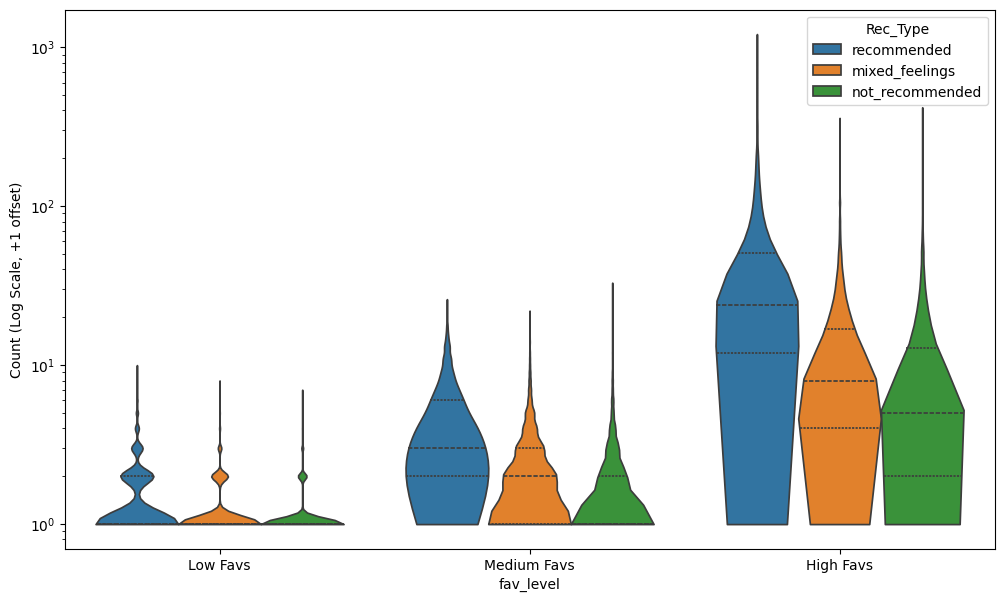

In [ ]:
melted_subset['Count_Adjusted'] = melted_subset['Count'] + 1

plt.figure(figsize=(12, 7))

sns.violinplot(
    data=melted_subset,
    x='fav_level',
    y='Count_Adjusted',
    hue='Rec_Type',
    cut=0,
    density_norm='width',
    inner='quartile'
)


plt.yscale('log')
plt.ylabel('Count (Log Scale, +1 offset)')


plt.show()

# Hypothesis Testing

## **1. Question:** Does the source material significantly impact the final score?

**Null Hypothesis:** The quality of product defined by score is not dependent on scource (all means are equal)

**Alternative Hypothethis:** The quality of product defined by score dependent on scource (at least one pair of mean is not equal)

**Significance Level:** 0.05

In [ ]:
test_df = df[['score', 'source']].copy()

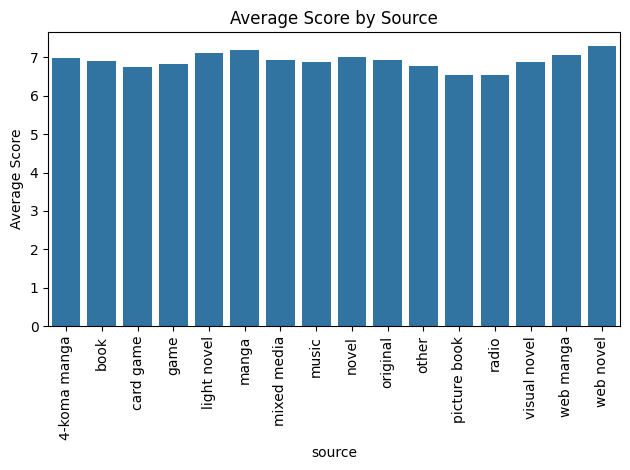

In [ ]:
vis = test_df.groupby('source')['score'].mean()

sns.barplot(x=vis.index, y=vis.values)
plt.xticks(rotation=90, ha = 'center')
plt.title('Average Score by Source')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

In [ ]:
print(test_df)

       score        source
0       9.27         manga
1       9.16         manga
2       9.11         manga
3       9.09         manga
4       9.07  visual novel
...      ...           ...
10137   6.13     web manga
10138   6.13         manga
10139   6.13      original
10140   6.13      original
10141   6.13         manga

[10142 rows x 2 columns]


In [ ]:
from scipy.stats import f_oneway

groups = [data['score'].values for name, data in df.groupby('source')]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")

F-statistic: 38.3147
P-value: 2.0550e-109


P-value < 0.05, therefore we reject null hypothetis, despite the fact that on plot it seems that everything is equal.

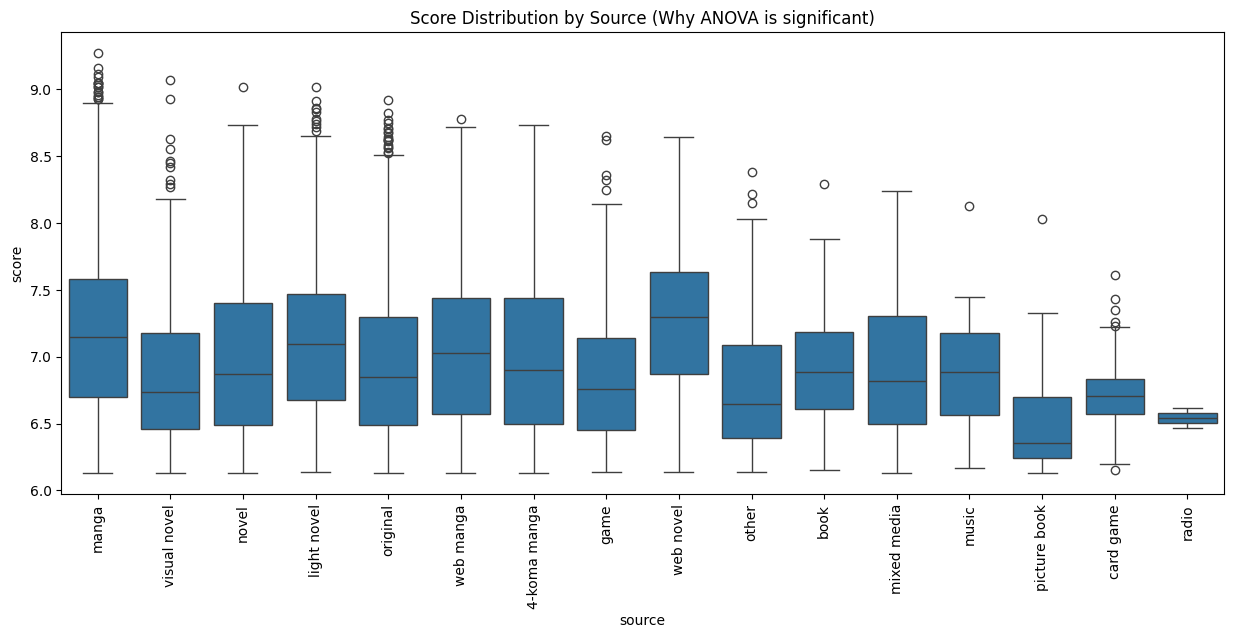

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

sns.boxplot(x='source', y='score', data=df)
plt.xticks(rotation=90)
plt.title("Score Distribution by Source (Why ANOVA is significant)")
plt.show()

So, now that we sure that means are not equal, we should conctruct Tukey Itervals to see, if any of them are equal.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

test_df_cleaned = test_df.dropna(subset=['source'])

tukey = pairwise_tukeyhsd(endog=test_df_cleaned['score'], groups=test_df_cleaned['source'], alpha=0.05)

print(tukey.summary())

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
4-koma manga         book  -0.0627    1.0 -0.3304   0.205  False
4-koma manga    card game  -0.2348 0.4792  -0.558  0.0884  False
4-koma manga         game  -0.1471 0.0735 -0.2998  0.0056  False
4-koma manga  light novel    0.138 0.0847 -0.0073  0.2834  False
4-koma manga        manga   0.2005    0.0   0.066   0.335   True
4-koma manga  mixed media  -0.0491    1.0 -0.2918  0.1935  False
4-koma manga        music   -0.096    1.0 -0.5385  0.3465  False
4-koma manga        novel   0.0207    1.0 -0.1414  0.1828  False
4-koma manga     original   -0.039 0.9999 -0.1761  0.0981  False
4-koma manga        other  -0.2152 0.0036 -0.3931 -0.0373   True
4-koma manga picture book  -0.4462 0.0005 -0.7789 -0.1135   True
4-koma manga        radio  -0.4365 0.9996  -1.845   0.972  False
4-koma manga visual novel

In [ ]:
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                        columns=tukey._results_table.data[0])

significant_pairs = tukey_df[tukey_df['reject'] == True]
significant_pairs = significant_pairs.sort_values(by='meandiff', ascending=False)

print(f"Total significant pairs found: {len(significant_pairs)}")
print(significant_pairs.head(20))

Total significant pairs found: 46
           group1        group2  meandiff   p-adj   lower   upper  reject
113  picture book     web novel    0.7543  0.0000  0.4257  1.0830    True
41      card game     web novel    0.5429  0.0000  0.2239  0.8619    True
112  picture book     web manga    0.5360  0.0000  0.2137  0.8582    True
109         other     web novel    0.5233  0.0000  0.3530  0.6935    True
53           game     web novel    0.4552  0.0000  0.3116  0.5989    True
31      card game         manga    0.4353  0.0001  0.1379  0.7327    True
118  visual novel     web novel    0.4145  0.0000  0.2500  0.5791    True
30      card game   light novel    0.3729  0.0026  0.0703  0.6754    True
28           book     web novel    0.3708  0.0002  0.1082  0.6335    True
83    mixed media     web novel    0.3572  0.0000  0.1201  0.5943    True
43           game         manga    0.3476  0.0000  0.2620  0.4333    True
104      original     web novel    0.3471  0.0000  0.2201  0.4740    True
111 

In [ ]:
print(significant_pairs['group2'][significant_pairs['meandiff']>0].value_counts())

group2
web novel       12
web manga        6
manga            4
light novel      2
visual novel     1
novel            1
original         1
Name: count, dtype: int64


From this dataset, we can conclude that if the source of anime is web novel, it is more likely to score high from audience.

##  **2. Question:** Are animes broadcasted on friday are more popular than those broadcasted on any other day of the week?

**Null Hypothesis**: Animes gain equal average popularity regardless broadcast day (Popularity level of friday-titles are equal to any other days)

**Alternative Hypothethis**: The mean popularity of titles broadcasted on Friday is significantly lower than the mean popularity of titles broadcasted on all other days combined.

**Significance level:** 0.05

In [ ]:
test_df = df[['popularity', 'broadcast_day']].copy()
test_df = test_df.dropna()

In [ ]:
from scipy.stats import kruskal

groups = [data['popularity'] for name, data in test_df.groupby('broadcast_day', observed = False)]

stat, p_val = kruskal(*groups)

print(f"P-value: {p_val}")

P-value: 0.02547783366651588


In [ ]:
from scipy import stats

test_df = df.dropna(subset=['members', 'broadcast_day']).copy()
test_df['log_members'] = np.log1p(test_df['members'])

friday = test_df['log_members'][test_df['broadcast_day'] == 'Friday']
other_days = test_df['log_members'][test_df['broadcast_day'] != 'Friday']

t_stat, p_value = stats.ttest_ind(friday, other_days, equal_var=False, alternative='greater')

print(f"T-statistic: {t_stat}, P-value: {p_value}")


T-statistic: 3.1826874624049872, P-value: 0.000755230348317765


Kruskal-Wallis test staded that there is a significant difference between popularity of animes broadcasted on different weekdays and t-test showed that friday animes are indeed statistically more popular.

## **3. Question:** Dramas score better than Actions?

**Null Hypothesis**: Dramas and Actions score likewise scores.

**Alternative Hypothethis**: Mean score of dramas is greater than mean score of actions.

**Significance level:** 0.05

In [ ]:
from scipy import stats

test_df = df.dropna(subset=['score', 'genres']).copy()
test_df = test_df.explode('genres')
test_df['score'] = (test_df['score'] - test_df['score'].min()) / (test_df['score'].max() - test_df['score'].min())


In [ ]:
drama_scores = test_df[test_df['genres'] == 'drama']['score']
action_scores = test_df[test_df['genres'] == 'action']['score']

t_stat, p_val = stats.ttest_ind(drama_scores, action_scores, nan_policy='omit', alternative='greater')

print(f"P-value: {p_val}")
if p_val < 0.05:
    print("Reject the Null Hypothesis: There is a significant difference.")
else:
    print("Fail to reject: No significant difference found.")

P-value: 1.5014996287707885e-07
Reject the Null Hypothesis: There is a significant difference.


According to the test, drama anime scores are greater than action-anime scores.

## **4. Question:** Newly-produced anime scores better on average than older ones?

**Null Hypothesis:** There is no significant difference between the mean scores of older and newer anime.

**Alternative Hypothesis:** Newer anime have a significantly higher mean score than older anime.

**Significance Level: 0.05**

In [ ]:
cutoff_year = 2015
old_anime = df[df['start_date'].dt.year < cutoff_year]['score'].dropna()
new_anime = df[df['start_date'].dt.year >= cutoff_year]['score'].dropna()

from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(new_anime, old_anime, equal_var=False)

print(f"Mean Score (Old): {old_anime.mean():.2f}")
print(f"Mean Score (New): {new_anime.mean():.2f}")
print(f"P-value: {p_val}")

Mean Score (Old): 6.99
Mean Score (New): 7.11
P-value: 7.298986732124217e-24


We fail to reject Null Hypothesis, since 7 is much greater than 0.05, so actually old animes averagely scores as much as newest ones.

## **5. Question:** Do some studios produce higher-quality anime?

**Null Hypothesis:** Score means of Top 20 Productive Studios is equal.

**Alternative Hypothesis:** Some studios do higher-scoring animes.

**Significance Level:** 0.05

In [ ]:
test_df = df[['score', 'studio']].copy()
test_df = test_df.explode('studio')

top20 = test_df.groupby('studio')['score'].count().sort_values(ascending=False).head(20)
print(top20)

studio
toei animation          610
sunrise                 460
j.c.staff               344
madhouse                307
production i.g          288
tms entertainment       283
studio deen             262
olm                     242
studio pierrot          225
a-1 pictures            217
shin-ei animation       205
nippon animation        170
bones                   147
xebec                   131
aic                     129
tatsunoko production    126
shaft                   121
kyoto animation         117
gonzo                   114
silver link.            114
Name: score, dtype: int64


In [ ]:
test_df = test_df[test_df['studio'].isin(top20.index)]

In [ ]:
print(test_df)

       score             studio
0       9.27           madhouse
2       9.11              bones
8       9.03           madhouse
10      9.02            sunrise
11      9.02            sunrise
...      ...                ...
10124   6.13  shin-ei animation
10125   6.13  shin-ei animation
10129   6.13  tms entertainment
10132   6.13  tms entertainment
10138   6.13     studio pierrot

[4612 rows x 2 columns]


In [ ]:
f, p = f_oneway(*[data['score'] for name, data in test_df.groupby('studio')])

print(f"F-statistic: {f:.4f}")
print(f"P-value: {p:.4e}")

F-statistic: 17.1428
P-value: 1.4774e-55


Since p-value is significantly lower than 0.05, some studios indeed produce more higher-scoring animes.

In [ ]:
studios = list(top20.index)
print(studios)

['toei animation', 'sunrise', 'j.c.staff', 'madhouse', 'production i.g', 'tms entertainment', 'studio deen', 'olm', 'studio pierrot', 'a-1 pictures', 'shin-ei animation', 'nippon animation', 'bones', 'xebec', 'aic', 'tatsunoko production', 'shaft', 'kyoto animation', 'gonzo', 'silver link.']


In [ ]:
combinations = []
for studio1 in studios:
  for studio2 in studios:
    if studio1 == studio2:
      continue
    else:
      combinations.append([studio1, studio2])

print(combinations)


[['toei animation', 'sunrise'], ['toei animation', 'j.c.staff'], ['toei animation', 'madhouse'], ['toei animation', 'production i.g'], ['toei animation', 'tms entertainment'], ['toei animation', 'studio deen'], ['toei animation', 'olm'], ['toei animation', 'studio pierrot'], ['toei animation', 'a-1 pictures'], ['toei animation', 'shin-ei animation'], ['toei animation', 'nippon animation'], ['toei animation', 'bones'], ['toei animation', 'xebec'], ['toei animation', 'aic'], ['toei animation', 'tatsunoko production'], ['toei animation', 'shaft'], ['toei animation', 'kyoto animation'], ['toei animation', 'gonzo'], ['toei animation', 'silver link.'], ['sunrise', 'toei animation'], ['sunrise', 'j.c.staff'], ['sunrise', 'madhouse'], ['sunrise', 'production i.g'], ['sunrise', 'tms entertainment'], ['sunrise', 'studio deen'], ['sunrise', 'olm'], ['sunrise', 'studio pierrot'], ['sunrise', 'a-1 pictures'], ['sunrise', 'shin-ei animation'], ['sunrise', 'nippon animation'], ['sunrise', 'bones'], [

In [ ]:
results = []

In [ ]:
for combination in combinations:
  studio1, studio2 = combination
  print('-'*100)
  print()
  print(f'Does {studio1} score more than {studio2}?')
  print()
  studio1_scores = test_df[test_df['studio'] == studio1]['score']
  studio2_scores = test_df[test_df['studio'] == studio2]['score']
  t_stat, p_val = ttest_ind(studio1_scores, studio2_scores, equal_var=False, alternative='greater')
  if p_val < 0.05:
    print('Yes')
    results.append(studio1)
  else:
    print('No')

----------------------------------------------------------------------------------------------------

Does toei animation score more than sunrise?

No
----------------------------------------------------------------------------------------------------

Does toei animation score more than j.c.staff?

No
----------------------------------------------------------------------------------------------------

Does toei animation score more than madhouse?

No
----------------------------------------------------------------------------------------------------

Does toei animation score more than production i.g?

No
----------------------------------------------------------------------------------------------------

Does toei animation score more than tms entertainment?

No
----------------------------------------------------------------------------------------------------

Does toei animation score more than studio deen?

No
----------------------------------------------------------------------

In [ ]:
print(len(results))

146


In [ ]:
scores_dictionary = {}

In [ ]:
for stud in results:
  if scores_dictionary.get(stud) == None:
    scores_dictionary[stud] = 1
  else:
    scores_dictionary[stud] += 1

In [ ]:
for key, value in scores_dictionary.items():
  print(f'{key} beat {value}.')

toei animation beat 4.
sunrise beat 7.
j.c.staff beat 7.
madhouse beat 12.
production i.g beat 14.
tms entertainment beat 10.
studio deen beat 10.
studio pierrot beat 7.
a-1 pictures beat 14.
shin-ei animation beat 4.
bones beat 16.
xebec beat 2.
shaft beat 14.
kyoto animation beat 19.
gonzo beat 2.
silver link. beat 4.


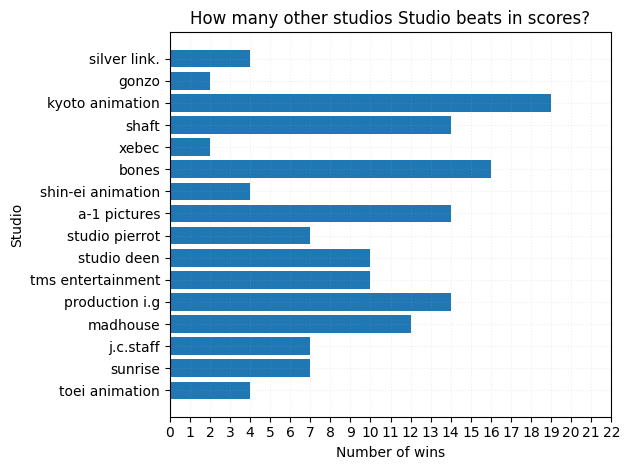

In [ ]:
plt.barh(list(scores_dictionary.keys()), list(scores_dictionary.values()))
plt.title('How many other studios Studio beats in scores?')
plt.xlabel('Number of wins')
plt.ylabel('Studio')
plt.xticks(np.arange(0, 23))
plt.grid(linestyle=':', alpha=0.2)
plt.tight_layout()
plt.show()

So, looking at the results of paired t-tests, we can see that Kyoto Animation beats 19 anime-studios ot of 20, and can be considered the highest scoring anime-studio of all times!

## **6. Question:** Are anime with "R - 17+ (violence & profanity)" ratings more popular (more members) than "PG" or "G" rated titles?

**Null Hypothesis**: Popularity distribution is the same across all rating categories.

**Alternative Hypothesis:** Mature-rated anime (R-17+) are significantly more popular than other ratings.

**Significance Level:** 0.05

In [ ]:
test_df = df[['popularity', 'rating']].copy()
test_df = test_df.dropna()

In [ ]:
print(test_df)

       popularity                          rating
0             104       pg-13 - teens 13 or older
1            1447  r - 17+ (violence & profanity)
2               3  r - 17+ (violence & profanity)
3             589  r - 17+ (violence & profanity)
4              14       pg-13 - teens 13 or older
...           ...                             ...
10137       15277                    g - all ages
10138       12374                    g - all ages
10139       11317       pg-13 - teens 13 or older
10140       15354                   pg - children
10141        8492  r - 17+ (violence & profanity)

[10088 rows x 2 columns]


In [ ]:
from scipy.stats import kruskal

groups = [data['popularity'] for name, data in test_df.groupby('rating', observed = False)]

stat, p_val = kruskal(*groups)

print(f"P-value: {p_val}")

P-value: 0.0


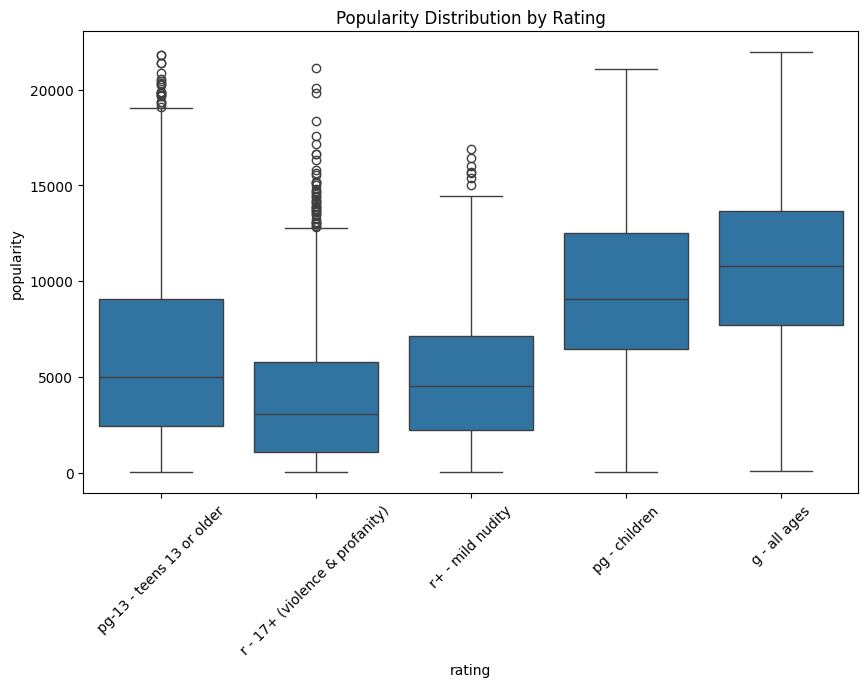

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='rating', y='popularity', data=test_df)
plt.xticks(rotation=45)
plt.title("Popularity Distribution by Rating")
plt.show()

In [ ]:
! pip install scikit_posthocs

In [ ]:
import scikit_posthocs as sp

dunn_rating = sp.posthoc_dunn(test_df, val_col='popularity', group_col='rating', p_adjust='holm')
print(dunn_rating)

                                 g - all ages  pg - children  \
g - all ages                     1.000000e+00   7.074458e-06   
pg - children                    7.074458e-06   1.000000e+00   
pg-13 - teens 13 or older       6.622054e-216   7.560649e-72   
r - 17+ (violence & profanity)  1.989261e-283  1.102928e-139   
r+ - mild nudity                2.103068e-121   9.855086e-61   

                                pg-13 - teens 13 or older  \
g - all ages                                6.622054e-216   
pg - children                                7.560649e-72   
pg-13 - teens 13 or older                    1.000000e+00   
r - 17+ (violence & profanity)               2.185935e-52   
r+ - mild nudity                             1.150234e-05   

                                r - 17+ (violence & profanity)  \
g - all ages                                     1.989261e-283   
pg - children                                    1.102928e-139   
pg-13 - teens 13 or older                         

In [ ]:
print(df.groupby('rating')['popularity'].mean())

rating
g - all ages                      10644.434524
pg - children                      9401.600587
pg-13 - teens 13 or older          6043.833629
r - 17+ (violence & profanity)     4011.179951
r+ - mild nudity                   5071.766719
Name: popularity, dtype: float64


From Kruskal-Wallis test results we can see that difference between popularity ranks of shows depending on rating is statistically different. From dunn test we can see that differnce between each pair is also significant. If we will look at means of popularity rank for each rating, we will see that the most popular rating is indeed r - 17+. So, reject null hypothesis.

## **7. Question:** TV vs Movies, which one is more popular?

**Null Hypothesis:** TV(series) animes and Movies are equally popular.

**Alternative hypothesis:** Popularity of series and movies is not equal.

**Significance level:** 0.05

In [ ]:
test_df = df[['members', 'show_type']].copy()
test_df = test_df.dropna()

test_df['members'] = (test_df['members'] - test_df['members'].mean()) / (np.sqrt(test_df['members'].var()))

tvs = test_df[test_df['show_type'] == 'tv']
movies = test_df[test_df['show_type'] == 'movie']

t_stat, p_value = ttest_ind(tvs['members'], movies['members'], equal_var=False)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 17.500717683933814, P-value: 6.43554806276864e-67


According to the results of test, we will reject null hypothesis, since p-value is smaller than 0.05. Since T-statistic is positive, we can assume that TV-shows are more popular than Movies.

## **8. Question:** Short animes are more popular than long-running ones?

**Null Hypothesis:** Number of episodes does not affect popularity/

**Alternative Hypothesis:** Popularity varies significantly depending on the number of episodes.

**Significance Level:** 0.05

In [ ]:
test_df = df[['members', 'episodes']].copy()
test_df = test_df.dropna()

test_df['episodes'] = test_df['episodes'][test_df['episodes']>2]

In [ ]:
short = test_df[test_df['episodes'] < 25]
longs = test_df[test_df['episodes'] >= 25]

In [ ]:
t_stat, p_value = ttest_ind(short['members'], longs['members'], equal_var=False, alternative = 'greater')

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 6.1112448975237195, P-value: 5.570139345867205e-10


Since p-value for this test is way less than 0.05, we will reject null hypothesis, accepting the fact that short animes are more popular.

In [ ]:
studs = df['studio'].copy()
studs = studs.explode()
print(studs.unique())

['madhouse' 'david production' 'bones' 'mappa' 'white fox'
 'bandai namco pictures' 'wit studio' 'k-factory'
 'kitty film mitaka studio' 'sunrise' 'toei animation' 'studio pierrot'
 'a-1 pictures' 'tms entertainment' 'kyoto animation' 'olm'
 'toho animation studio' 'shaft' 'studio signpost' 'comix wave films'
 'tokyo movie shinsha' 'shuka' 'production i.g' 'studio ghibli' 'enishiya'
 'bug films' 'cloverworks' 'bones film' 'artland' 'doga kobo'
 'dandelion animation studio' 'ufotable' 'lan studio' 'studio deen'
 'shin-ei animation' 'pb animation' 'paper plane animation studio'
 'b.cool studio' 'cygamespictures' 'pierrot films' 'gainax'
 'red dog culture house' 'b.cmay pictures' "brain's base" 'p.i.c.s.'
 'tatsunoko production' 'trigger' 'studio durian' 'hmch' 'kinema citrus'
 'studio bind' 'khara' 'studio chizu' 'original force'
 'wonder cat animation' 'studio voln' 'j.c.staff' 'manglobe' 'lerche'
 'zero-g' 'liber' 'c-station' 'studio colorido' 'studio chromato'
 'hal film maker' 'build